## About this fork

Based on [Tufa Labs’ Duck harness — June 30 milestone winner](https://www.kaggle.com/code/jeroencottaar/tufa-labs-duck-harness-june-30-milestone-winner). Full credit to Jeroen Cottaar and Tufa Labs for the original Duck solver and harness.

The Duck prompts, tool-use loop, game policy, and scorer remain unchanged. My changes are limited to model serving and performance:

- Replaced the original Qwen3.6-27B-FP8 serving stack with the pinned `RadixArk/Qwen3.8-Flash-Next-NVFP4` checkpoint.
- Inference optimization: ModelOpt NVFP4 weights, BF16 compute, async scheduling, chunked prefill, native three-token NEXTN MTP speculative decoding32K context, an 8K batched-token cap, eight vLLM sequences, CUDA graphs, disabled prefix caching, and disabled request/access logs. Duck retains 28-way game concurrency.
- Added a pinned offline vLLM runtime and compatibility patch required for the model’s FP8 PLE layers.
- Added an owned-server watchdog that checks `/v1/models`, restarts only after four consecutive failures, confirms the old process and port are gone, and permits at most two restarts.

# Tufa Labs ARC3 submission

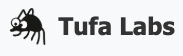

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# Skip periodic JSON/HTML diagnostics and per-frame logging for every run.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1"

# Apply the measured vLLM winner before any serving setup command runs.
PUBLIC25_VLLM_PROFILE_NAME = 'kv5-bf16-mtp3-c8-cg32'
PUBLIC25_VLLM_PROFILE_ENV = {
    "TAAF_VLLM_ENABLE_PREFIX_CACHING": "0",
    "TAAF_VLLM_KV_CACHE_DTYPE": "auto",
    "TAAF_VLLM_KV_CACHE_MEMORY_BYTES": "5368709120",
    "TAAF_VLLM_MAX_CUDAGRAPH_CAPTURE_SIZE": "32",
    "TAAF_VLLM_MAX_NUM_BATCHED_TOKENS": "8192",
    "TAAF_VLLM_MAX_NUM_SEQS": "8",
    "TAAF_VLLM_MTP_TOKENS": "3",
    "TAAF_VLLM_OMP_THREADS": "1"
}
for key, value in PUBLIC25_VLLM_PROFILE_ENV.items():
    os.environ[key] = value
print(
    f'PUBLIC25_VLLM_PROFILE name={PUBLIC25_VLLM_PROFILE_NAME} '
    f'env={json.dumps(PUBLIC25_VLLM_PROFILE_ENV, sort_keys=True)}',
    flush=True,
)
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["keithtyser/duck-qwen38-nvfp4-mtp-vllm-smoke-v1", "keithtyser/qwen38-flash-next-vllm-nvfp4-runtime-v1"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands â€” installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts â€” the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Exact public-25 and competition settings.
bm.solver.max_runtime_s_per_game = 7920.0
bm.solver.analyzer_timeout = 900.0
bm.solver.concurrency = 28
bm.solver.max_actions_per_game = None
bm.solver.save_request_logs = False
if float(getattr(target, 'max_runtime_s', 0.0) or 0.0) != 32400.0:
    raise RuntimeError(
        f'Expected the 32400-second notebook budget, got {target.max_runtime_s!r}.'
    )
print(
    f'PUBLIC25_SETTINGS budget_s={bm.solver.max_runtime_s_per_game} '
    f'concurrency={bm.solver.concurrency} analyzer_timeout={bm.solver.analyzer_timeout} '
    f'action_cap={bm.solver.max_actions_per_game} request_logs={bm.solver.save_request_logs}',
    flush=True,
)


In [ ]:
# INJERTOS taaf_grafts (nuestros) SOBRE EL STACK NVFP4 — kernel de EXPERIMENTO.
# Brazo "base de mas puntaje + lo nuestro", UNA variable: los tres injertos de v23
# (efficiency, retry_guard, schema_helpers). shortcircuit OFF como en v23.
#
# Van EMBEBIDOS (15 modulos, byte a byte, tal como corren en v23) y no como dataset:
# el bundle NVFP4 no trae taaf-grafts, y adjuntar el fork de thtennant colisiona con
# _find_bundle_dir() (misma etiqueta duck-harness-kaggle, rglob devuelve el primero).
# composite.install restaura stock ante cualquier error: el peor caso es NVFP4 plano.
try:
    import base64 as _b64g
    import sys as _sysg
    from pathlib import Path as _PathG
    _root = _PathG(WORKING_DIR) / "taaf_grafts_vendored"
    _pkg = _root / "taaf_grafts"
    _pkg.mkdir(parents=True, exist_ok=True)
    _files = {"__init__.py": "IiIiR3JhZnQgbW9kdWxlcyBmb3IgdGhlIGZvcmtlZCBkdWNrIGhhcm5lc3MgKGFzc2lnbmVkIGluIG5vdGVib29rIGNlbGwgMTIpLgoKRXZlcnl0aGluZyBpbiB0aGlzIHBhY2thZ2UgbXVzdCBpbXBvcnQgY2xlYW5seSB3aXRoIG9ubHkgdGhlIHZlbmRvcmVkCmBgdHVmYS1hcmMtYWdpLWZyYW1ld29ya2BgIC8gYGBBUkMzLUluZmVyZW5jZWBgIHRyZWVzIG9uIGBgc3lzLnBhdGhgYCDigJQgb24KS2FnZ2xlIHRoYXQgaXMgZXhhY3RseSB3aGF0IGNlbGwgOCBwcm92aWRlcywgbG9jYWxseSBgYHRhYWZfcmlnL2Vudi5weWBgCnByb3ZpZGVzIHRoZSBzYW1lLiBObyBtb2R1bGUgaGVyZSBtYXkgc3RhcnQgR1BVIHdvcmsgYXQgaW1wb3J0IHRpbWUuCiIiIgoKZnJvbSB0YWFmX2dyYWZ0cy5iYW5raW5nX3NvbHZlciBpbXBvcnQgQmFua2luZ0hhcm5lc3NTb2x2ZXIKCl9fYWxsX18gPSBbIkJhbmtpbmdIYXJuZXNzU29sdmVyIl0K", "agent_ext.py": "...", "banking_solver.py": "IiIiV2luLXRoZW4tcmVwbGF5IGJhbmtpbmcgc29sdmVyIChiYXR0bGUtcGxhbiBTVEVQIDRiIC8gd2Vlay1wbGFuIERlbHRhIDMpLgoKRW5naW5lIGZhY3RzIHRoaXMgZ3JhZnQgaXMgYnVpbHQgb24gKGFsbCB2ZXJpZmllZCBhZ2FpbnN0IHRoZSB2ZW5kb3JlZApzb3VyY2VzIGFuZCBgYGFyY19hZ2lgYCAwLjkuOCAvIGBgYXJjZW5naW5lYGAgMC45LjMpOgoKLSBBIHNjb3JlY2FyZCBjYXJkJ3Mgc2NvcmUgaXMgdGhlIE1BWCBvdmVyIGl0cyBwbGF5cwogIChgYGFyY19hZ2kuc2NvcmVjYXJkLkVudmlyb25tZW50U2NvcmVMaXN0LnNjb3JlYGApLgotIFJFU0VUIGlzc3VlZCB3aGlsZSB0aGUgZW5naW5lIGlzIGluIHRoZSBXSU4gc3RhdGUgcGVyZm9ybXMgYSAqZnVsbCoKICByZXNldCBldmVuIHVuZGVyIGBgT05MWV9SRVNFVF9MRVZFTFM9dHJ1ZWBgIChgYGFyY2VuZ2luZS5iYXNlX2dhbWUKICAuaGFuZGxlX3Jlc2V0YGApLCBhbmQgYSBmdWxsIHJlc2V0IG9wZW5zIGEgTkVXIHBsYXkgb24gdGhlIFNBTUUgY2FyZAogIChgYFNjb3JlY2FyZC51cGRhdGVfc2NvcmVjYXJkYGAgLT4gYGBuZXdfcGxheWBgKS4KLSBgYHRhYWYuZ2FtZS5HYW1lLmV4ZWN1dGVfYWN0aW9uYGAgcmVmdXNlcyB0byBydW4gb25jZSB0aGUgYGBHYW1lUnVuYGAKICBpcyBgYCJ3b24iYGAsIHNvIHRoZSByZXBsYXkgbXVzdCBkcml2ZSB0aGUgdW5kZXJseWluZwogIGBgYXJjX2FnaS5FbnZpcm9ubWVudFdyYXBwZXJgYCAoYGBHYW1lQVBJLmVudmBgKSBkaXJlY3RseS4gVGhhdCBrZWVwcwogIHRoZSBmcmFtZXdvcmstc2lkZSB3aW4gcmVjb3JkIHVudG91Y2hlZCB3aGlsZSB0aGUgZW5naW5lL2dhdGV3YXkKICBzY29yZXMgdGhlIHNlY29uZCBwbGF5LgoKU3RyYXRlZ3k6IG9uY2UgYSBzZXNzaW9uJ3MgV0lOIGlzIGZ1bGx5IHJlY29yZGVkLCBwcnVuZSB0aGUgd2lubmluZwp0cmFjZSBwZXIgbGV2ZWwgKGRyb3AgYWN0aW9ucyB0aGF0IGNoYW5nZWQgbmVpdGhlciB0aGUgZnJhbWUgbm9yCmBgbGV2ZWxzX2NvbXBsZXRlZGBgOyBhIFJFU0VUIHZvaWRzIGV2ZXJ5dGhpbmcgc2luY2UgdGhlIGxldmVsIHN0YXJ0ZWQpCmFuZCByZXBsYXkgaXQgb24gYSBmcmVzaCBwbGF5IG9mIHRoZSBzYW1lIGNhcmQuIEV2ZXJ5IHJlcGxheWVkIGFjdGlvbiBpcwpjaGVja2VkIGFnYWluc3QgdGhlIHJlY29yZGVkIGZyYW1lIGFuZCBsZXZlbCBjb3VudDsgYW55IGRpdmVyZ2VuY2UKYWJvcnRzIHRoZSByZXBsYXkgaW1tZWRpYXRlbHkuIEFib3J0aW5nIGlzIGZyZWUg4oCUIHRoZSByZWNvcmRlZCB3aW4gc3RpbGwKb3ducyB0aGUgY2FyZCBtYXgg4oCUIHNvIGV2ZXJ5IGd1YXJkIGluIGhlcmUgZmFpbHMgdG93YXJkICJkbyBub3RoaW5nIi4KIiIiCgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFubm90YXRpb25zCgppbXBvcnQgdGltZQpmcm9tIGRhdGFjbGFzc2VzIGltcG9ydCBkYXRhY2xhc3MsIGZpZWxkLCBmaWVsZHMKZnJvbSB0eXBpbmcgaW1wb3J0IEFueQoKaW1wb3J0IGFyY2VuZ2luZQoKZnJvbSBpbmZlcmVuY2UuZnJhbWV3b3JrLnNvbHZlciBpbXBvcnQgKAogICAgSGFybmVzc1NvbHZlciwKICAgIF9ncmlkX2Zyb21fc3RhdGUsCiAgICBfSGFybmVzc0dhbWVTZXNzaW9uLAopCgpmcm9tIHRhYWZfZ3JhZnRzLnNvbHZlcl9iYXNlIGltcG9ydCBTZXNzaW9uU2VhbU1peGluCgpHcmlkID0gdHVwbGVbdHVwbGVbaW50LCAuLi5dLCAuLi5dCgoKY2xhc3MgQmFua2luZ1BsYW5FcnJvcihWYWx1ZUVycm9yKToKICAgICIiIlRoZSByZWNvcmRlZCB0cmFjZSBjYW5ub3QgYmUgdHVybmVkIGludG8gYSB0cnVzdHdvcnRoeSByZXBsYXkgcGxhbi4iIiIKCgpAZGF0YWNsYXNzKGZyb3plbj1UcnVlKQpjbGFzcyBUcmFjZVN0ZXA6CiAgICAiIiJPbmUgZXhlY3V0ZWQgZW5naW5lIGFjdGlvbiB3aXRoIHRoZSBzdGF0ZSBpdCBwcm9kdWNlZC4iIiIKCiAgICBhY3Rpb25faWQ6IGFyY2VuZ2luZS5HYW1lQWN0aW9uCiAgICBhY3Rpb25fZGF0YTogZGljdFtzdHIsIEFueV0KICAgIGdyaWQ6IEdyaWQKICAgIGxldmVsc19jb21wbGV0ZWQ6IGludAogICAgc3RhdGU6IGFyY2VuZ2luZS5HYW1lU3RhdGUKCgpkZWYgcHJ1bmVfd2lubmluZ190cmFjZSgKICAgIHRyYWNlOiBsaXN0W1RyYWNlU3RlcF0sCiAgICBpbml0aWFsX2dyaWQ6IEdyaWQsCiAgICBudW1iZXJfb2ZfbGV2ZWxzOiBpbnQsCikgLT4gbGlzdFtUcmFjZVN0ZXBdOgogICAgIiIiUmV0dXJuIHRoZSBwcnVuZWQgcmVwbGF5IHBsYW4gZm9yIGEgcmVjb3JkZWQgd2lubmluZyB0cmFjZS4KCiAgICBQZXIgbGV2ZWwsIG9ubHkgdGhlIHNlZ21lbnQgYWZ0ZXIgdGhlIGxhc3QgUkVTRVQgKG1pZC1sZXZlbCBSRVNFVHMg4oCUCiAgICBpbmNsdWRpbmcgdGhlIGhhcm5lc3MgYXV0by1SRVNFVCBhZnRlciBHQU1FX09WRVIg4oCUIHJlc3RhcnQgdGhlIGxldmVsLAogICAgdm9pZGluZyBldmVyeXRoaW5nIGJlZm9yZSB0aGVtKSBzdXJ2aXZlcywgbWludXMgYWN0aW9ucyB0aGF0IG5laXRoZXIKICAgIGNoYW5nZWQgdGhlIHZpc2libGUgZnJhbWUgbm9yIGFkdmFuY2VkIGBgbGV2ZWxzX2NvbXBsZXRlZGBgLiBBbgogICAgYWN0aW9uIHRoYXQgYWR2YW5jZXMgYGBsZXZlbHNfY29tcGxldGVkYGAgaXMgYWx3YXlzIGtlcHQuCgogICAgUmFpc2VzIDpjbGFzczpgQmFua2luZ1BsYW5FcnJvcmAgd2hlbiB0aGUgdHJhY2UgZG9lcyBub3QgZGVzY3JpYmUgYQogICAgY2xlYW4gd2luIChkZWZlbnNpdmU6IHJlcGxheWluZyBhIGdhcmJsZWQgcGxhbiByaXNrcyBub3RoaW5nIHNjb3JlLQogICAgd2lzZSwgYnV0IHRoZXJlIGlzIG5vIHBvaW50IHNlbmRpbmcgYWN0aW9ucyB3ZSBjYW5ub3QgdmVyaWZ5KS4KICAgICIiIgogICAgaWYgbm90IHRyYWNlOgogICAgICAgIHJhaXNlIEJhbmtpbmdQbGFuRXJyb3IoImVtcHR5IHRyYWNlIikKICAgIGlmIHRyYWNlWy0xXS5zdGF0ZSAhPSBhcmNlbmdpbmUuR2FtZVN0YXRlLldJTjoKICAgICAgICByYWlzZSBCYW5raW5nUGxhbkVycm9yKGYidHJhY2UgZW5kcyBpbiB7dHJhY2VbLTFdLnN0YXRlLm5hbWV9LCBub3QgV0lOIikKCiAgICBwbGFuOiBsaXN0W1RyYWNlU3RlcF0gPSBbXQogICAgcGVuZGluZzogbGlzdFtUcmFjZVN0ZXBdID0gW10gICMga2VwdCBhY3Rpb25zIG9mIHRoZSBsZXZlbCBpbiBwcm9ncmVzcwogICAgcHJldl9ncmlkID0gaW5pdGlhbF9ncmlkCiAgICBwcmV2X2xldmVscyA9IDAKICAgIGZvciBzdGVwIGluIHRyYWNlOgogICAgICAgIGlmIHN0ZXAuYWN0aW9uX2lkID09IGFyY2VuZ2luZS5HYW1lQWN0aW9uLlJFU0VUOgogICAgICAgICAgICBwZW5kaW5nID0gW10KICAgICAgICAgICAgcHJldl9ncmlkID0gc3RlcC5ncmlkCiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgaWYgc3RlcC5sZXZlbHNfY29tcGxldGVkID4gcHJldl9sZXZlbHM6CiAgICAgICAgICAgIHBlbmRpbmcuYXBwZW5kKHN0ZXApCiAgICAgICAgICAgIHBsYW4uZXh0ZW5kKHBlbmRpbmcpCiAgICAgICAgICAgIHBlbmRpbmcgPSBbXQogICAgICAgICAgICBwcmV2X2xldmVscyA9IHN0ZXAubGV2ZWxzX2NvbXBsZXRlZAogICAgICAgIGVsaWYgc3RlcC5ncmlkICE9IHByZXZfZ3JpZDoKICAgICAgICAgICAgcGVuZGluZy5hcHBlbmQoc3RlcCkKICAgICAgICAjIGVsc2U6IG5vIGZyYW1lIGNoYW5nZSwgbm8gbGV2ZWwgcHJvZ3Jlc3Mg4oCUIHBydW5hYmxlIG5vLW9wLgogICAgICAgIHByZXZfZ3JpZCA9IHN0ZXAuZ3JpZAogICAgaWYgcGVuZGluZzoKICAgICAgICByYWlzZSBCYW5raW5nUGxhbkVycm9yKCJ0cmFpbGluZyBhY3Rpb25zIGFmdGVyIHRoZSBsYXN0IGxldmVsIGFkdmFuY2UiKQogICAgaWYgcHJldl9sZXZlbHMgIT0gbnVtYmVyX29mX2xldmVsczoKICAgICAgICByYWlzZSBCYW5raW5nUGxhbkVycm9yKAogICAgICAgICAgICBmInRyYWNlIGNvdmVycyB7cHJldl9sZXZlbHN9L3tudW1iZXJfb2ZfbGV2ZWxzfSBsZXZlbHMiCiAgICAgICAgKQogICAgcmV0dXJuIHBsYW4KCgpkZWYgX2dyaWRfZnJvbV9mcmFtZV9yYXcocmVzcDogQW55KSAtPiBHcmlkOgogICAgIiIiRmluYWwgdmlzaWJsZSBmcmFtZSBvZiBhIGBgRnJhbWVEYXRhUmF3YGAgYXMgYSBoYXNoYWJsZSBncmlkLiIiIgogICAgZGF0YSA9IHJlc3AuZnJhbWVbLTFdCiAgICByb3dzID0gZGF0YS50b2xpc3QoKSBpZiBoYXNhdHRyKGRhdGEsICJ0b2xpc3QiKSBlbHNlIGRhdGEKICAgIHJldHVybiB0dXBsZSh0dXBsZShpbnQoY2VsbCkgZm9yIGNlbGwgaW4gcm93KSBmb3Igcm93IGluIHJvd3MpCgoKQGRhdGFjbGFzcwpjbGFzcyBfQmFua2luZ0dhbWVTZXNzaW9uKF9IYXJuZXNzR2FtZVNlc3Npb24pOgogICAgIiIiSGFybmVzcyBzZXNzaW9uIHRoYXQgcmVjb3JkcyBhIHJlcGxheWFibGUgdHJhY2UgYW5kLCBvbiBXSU4sIGJhbmtzCiAgICBhIHBydW5lZCByZXBsYXkgYXMgYSBzZWNvbmQgcGxheSBvZiB0aGUgc2FtZSBjYXJkIGJlZm9yZSB0aGUgZ2FtZSBpcwogICAgZmluaXNoZWQgKGBgZmluaXNoX2dhbWVgYCBtdXN0IHJ1biBsYXN0OiBpbiBjb21wZXRpdGlvbiBtb2RlIGl0IGZpcmVzCiAgICB0aGUgc2hhcmVkIHNjb3JlY2FyZCdzIGBgZmluaXNoX3J1bmBgLCBhbmQgdGhlIExBU1Qgb25lIGNsb3NlcyB0aGUKICAgIGNhcmQpLiIiIgoKICAgIF90cmFjZTogbGlzdFtUcmFjZVN0ZXBdID0gZmllbGQoZGVmYXVsdF9mYWN0b3J5PWxpc3QsIGluaXQ9RmFsc2UsIHJlcHI9RmFsc2UpCiAgICBfYmFua2luZ19hdHRlbXB0ZWQ6IGJvb2wgPSBmaWVsZChkZWZhdWx0PUZhbHNlLCBpbml0PUZhbHNlLCByZXByPUZhbHNlKQoKICAgICMgLS0gdHJhY2UgcmVjb3JkaW5nIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQoKICAgIGRlZiBfZXhlY3V0ZV9hY3Rpb24oCiAgICAgICAgc2VsZiwKICAgICAgICBhY3Rpb246IGFyY2VuZ2luZS5BY3Rpb25JbnB1dCwKICAgICAgICAqLAogICAgICAgIGJhdGNoX2luZGV4OiBpbnQsCiAgICAgICAgYmF0Y2hfc2l6ZTogaW50LAogICAgICAgIGdlbmVyYXRlZF90b2tlbnM6IGludCB8IE5vbmUgPSBOb25lLAogICAgICAgIGZsdXNoX3ZpZXdlcl9wYXlsb2FkOiBib29sID0gVHJ1ZSwKICAgICkgLT4gZGljdFtzdHIsIEFueV06CiAgICAgICAgcGF5bG9hZCA9IHN1cGVyKCkuX2V4ZWN1dGVfYWN0aW9uKAogICAgICAgICAgICBhY3Rpb24sCiAgICAgICAgICAgIGJhdGNoX2luZGV4PWJhdGNoX2luZGV4LAogICAgICAgICAgICBiYXRjaF9zaXplPWJhdGNoX3NpemUsCiAgICAgICAgICAgIGdlbmVyYXRlZF90b2tlbnM9Z2VuZXJhdGVkX3Rva2VucywKICAgICAgICAgICAgZmx1c2hfdmlld2VyX3BheWxvYWQ9Zmx1c2hfdmlld2VyX3BheWxvYWQsCiAgICAgICAgKQogICAgICAgICMgZ2FtZS5leGVjdXRlX2FjdGlvbiByYWlzZWQgPT4gbm90aGluZyByZWNvcmRlZCBvbiBlaXRoZXIgc2lkZSwKICAgICAgICAjIHNvIHRyYWNlIGFuZCBnYW1lX3J1bi5oaXN0b3J5IHN0YXkgMToxLgogICAgICAgIHN0YXRlID0gc2VsZi5nYW1lLmN1cnJlbnRfc3RhdGUKICAgICAgICBzZWxmLl90cmFjZS5hcHBlbmQoCiAgICAgICAgICAgIFRyYWNlU3RlcCgKICAgICAgICAgICAgICAgIGFjdGlvbl9pZD1hY3Rpb24uaWQsCiAgICAgICAgICAgICAgICBhY3Rpb25fZGF0YT1kaWN0KGFjdGlvbi5kYXRhKSwKICAgICAgICAgICAgICAgIGdyaWQ9X2dyaWRfZnJvbV9zdGF0ZShzdGF0ZSksCiAgICAgICAgICAgICAgICBsZXZlbHNfY29tcGxldGVkPWludChzdGF0ZS5sZXZlbHNfY29tcGxldGVkKSwKICAgICAgICAgICAgICAgIHN0YXRlPXN0YXRlLnJhdy5zdGF0ZSwKICAgICAgICAgICAgKQogICAgICAgICkKICAgICAgICByZXR1cm4gcGF5bG9hZAoKICAgICMgLS0gYmFua2luZyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tCgogICAgZGVmIF9maW5pc2hfaWZfbmVlZGVkKHNlbGYpIC0+IE5vbmU6CiAgICAgICAgdHJ5OgogICAgICAgICAgICBzZWxmLl9tYXliZV9iYW5rX3dpbigpCiAgICAgICAgZXhjZXB0IEV4Y2VwdGlvbiBhcyBleGM6ICAjIG5vcWE6IEJMRTAwMSDigJQgYmFua2luZyBtdXN0IG5ldmVyIGJsb2NrIGNvbXBsZXRpb24KICAgICAgICAgICAgc2VsZi5fbm90ZV9iYW5raW5nKGYiZXJyb3Ige3R5cGUoZXhjKS5fX25hbWVfX306IHtleGN9IikKICAgICAgICBzdXBlcigpLl9maW5pc2hfaWZfbmVlZGVkKCkKCiAgICBkZWYgX21heWJlX2Jhbmtfd2luKHNlbGYpIC0+IE5vbmU6CiAgICAgICAgaWYgc2VsZi5fYmFua2luZ19hdHRlbXB0ZWQ6CiAgICAgICAgICAgIHJldHVybgogICAgICAgIHNlbGYuX2JhbmtpbmdfYXR0ZW1wdGVkID0gVHJ1ZQoKICAgICAgICBzb2x2ZXIgPSBzZWxmLnNvbHZlcgogICAgICAgIGlmIG5vdCBnZXRhdHRyKHNvbHZlciwgImJhbmtpbmdfZW5hYmxlZCIsIEZhbHNlKToKICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgcnVuID0gc2VsZi5nYW1lLmdhbWVfcnVuCiAgICAgICAgIyBCYW5rIHN0cmljdGx5IEFGVEVSIGEgZnVsbHkgcmVjb3JkZWQgV0lOIGFuZCBzdHJpY3RseSBCRUZPUkUKICAgICAgICAjIGZpbmlzaF9nYW1lIChmaW5hbF9zY29yZSBpcyBOb25lIHVudGlsIHRoZW4pLgogICAgICAgIGlmIHJ1biBpcyBOb25lIG9yIHJ1bi5zdGF0ZSAhPSAid29uIiBvciBydW4uZmluYWxfc2NvcmUgaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHJldHVybgogICAgICAgIGlmIHNlbGYuc3RvcF9ldmVudC5pc19zZXQoKToKICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgZW52ID0gZ2V0YXR0cihzZWxmLmdhbWUsICJlbnYiLCBOb25lKQogICAgICAgIGlmIGVudiBpcyBOb25lOiAgIyBub3QgYW4gZW5naW5lLWJhY2tlZCBnYW1lCiAgICAgICAgICAgIHJldHVybgogICAgICAgIGlmIGxlbihzZWxmLl90cmFjZSkgIT0gbGVuKHJ1bi5oaXN0b3J5KSBvciBub3Qgc2VsZi5oaXN0b3J5X2VudHJpZXM6CiAgICAgICAgICAgIHNlbGYuX25vdGVfYmFua2luZygic2tpcDogdHJhY2UvaGlzdG9yeSBtaXNhbGlnbmVkIikKICAgICAgICAgICAgcmV0dXJuCgogICAgICAgIHRyeToKICAgICAgICAgICAgcGxhbiA9IHBydW5lX3dpbm5pbmdfdHJhY2UoCiAgICAgICAgICAgICAgICBzZWxmLl90cmFjZSwKICAgICAgICAgICAgICAgIHNlbGYuaGlzdG9yeV9lbnRyaWVzWzBdLmZyYW1lLmdyaWQsCiAgICAgICAgICAgICAgICBpbnQoc2VsZi5nYW1lLm51bWJlcl9vZl9sZXZlbHMpLAogICAgICAgICAgICApCiAgICAgICAgZXhjZXB0IEJhbmtpbmdQbGFuRXJyb3IgYXMgZXhjOgogICAgICAgICAgICBzZWxmLl9ub3RlX2JhbmtpbmcoZiJza2lwOiB7ZXhjfSIpCiAgICAgICAgICAgIHJldHVybgoKICAgICAgICBvcmlnaW5hbCA9IHN1bSgKICAgICAgICAgICAgMSBmb3IgcyBpbiBzZWxmLl90cmFjZSBpZiBzLmFjdGlvbl9pZCAhPSBhcmNlbmdpbmUuR2FtZUFjdGlvbi5SRVNFVAogICAgICAgICkKICAgICAgICBpZiBsZW4ocGxhbikgPj0gb3JpZ2luYWw6CiAgICAgICAgICAgIHNlbGYuX25vdGVfYmFua2luZyhmInNraXA6IG5vdGhpbmcgdG8gcHJ1bmUgKHtvcmlnaW5hbH0gYWN0aW9ucykiKQogICAgICAgICAgICByZXR1cm4KICAgICAgICBtYXhfcmVwbGF5ID0gZ2V0YXR0cihzb2x2ZXIsICJiYW5raW5nX21heF9yZXBsYXlfYWN0aW9ucyIsIE5vbmUpCiAgICAgICAgaWYgbWF4X3JlcGxheSBpcyBub3QgTm9uZSBhbmQgbGVuKHBsYW4pID4gaW50KG1heF9yZXBsYXkpOgogICAgICAgICAgICBzZWxmLl9ub3RlX2JhbmtpbmcoCiAgICAgICAgICAgICAgICBmInNraXA6IHBsYW4ge2xlbihwbGFuKX0gPiBiYW5raW5nX21heF9yZXBsYXlfYWN0aW9ucyB7bWF4X3JlcGxheX0iCiAgICAgICAgICAgICkKICAgICAgICAgICAgcmV0dXJuCgogICAgICAgIGJ1ZGdldCA9IHNlbGYuX3JlcGxheV9idWRnZXRfc2Vjb25kcygpCiAgICAgICAgbmVlZGVkID0gbGVuKHBsYW4pICogZmxvYXQoc29sdmVyLmJhbmtpbmdfc2Vjb25kc19wZXJfYWN0aW9uKSArIGZsb2F0KAogICAgICAgICAgICBzb2x2ZXIuYmFua2luZ19maW5pc2hfbWFyZ2luX3MKICAgICAgICApCiAgICAgICAgaWYgYnVkZ2V0IGlzIG5vdCBOb25lIGFuZCBidWRnZXQgPCBuZWVkZWQ6CiAgICAgICAgICAgIHNlbGYuX25vdGVfYmFua2luZygKICAgICAgICAgICAgICAgIGYic2tpcDogYnVkZ2V0IHtidWRnZXQ6LjBmfXMgPCBlc3RpbWF0ZWQge25lZWRlZDouMGZ9cyIKICAgICAgICAgICAgKQogICAgICAgICAgICByZXR1cm4KCiAgICAgICAgc2VsZi5fcmVwbGF5KGVudiwgcGxhbiwgb3JpZ2luYWwsIGJ1ZGdldCkKCiAgICBkZWYgX3JlcGxheV9idWRnZXRfc2Vjb25kcyhzZWxmKSAtPiBmbG9hdCB8IE5vbmU6CiAgICAgICAgY2FuZGlkYXRlczogbGlzdFtmbG9hdF0gPSBbXQogICAgICAgIHJlbWFpbmluZyA9IHNlbGYudGltaW5nX3BheWxvYWQoKVsidGltZV9yZW1haW5pbmdfc2Vjb25kcyJdCiAgICAgICAgaWYgcmVtYWluaW5nIGlzIG5vdCBOb25lOgogICAgICAgICAgICBjYW5kaWRhdGVzLmFwcGVuZChmbG9hdChyZW1haW5pbmcpKQogICAgICAgIHNvZnRfcmVtYWluaW5nID0gc2VsZi5zb2x2ZXIuc29mdF90aW1lX3JlbWFpbmluZ19zZWNvbmRzKCkKICAgICAgICBpZiBzb2Z0X3JlbWFpbmluZyBpcyBub3QgTm9uZToKICAgICAgICAgICAgY2FuZGlkYXRlcy5hcHBlbmQoZmxvYXQoc29mdF9yZW1haW5pbmcpKQogICAgICAgIGlmIG5vdCBjYW5kaWRhdGVzOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgICAgIHJldHVybiBtaW4oY2FuZGlkYXRlcykKCiAgICBkZWYgX3JlcGxheSgKICAgICAgICBzZWxmLAogICAgICAgIGVudjogQW55LAogICAgICAgIHBsYW46IGxpc3RbVHJhY2VTdGVwXSwKICAgICAgICBvcmlnaW5hbF9hY3Rpb25zOiBpbnQsCiAgICAgICAgYnVkZ2V0OiBmbG9hdCB8IE5vbmUsCiAgICApIC0+IE5vbmU6CiAgICAgICAgbWFyZ2luID0gZmxvYXQoc2VsZi5zb2x2ZXIuYmFua2luZ19maW5pc2hfbWFyZ2luX3MpCiAgICAgICAgZGVhZGxpbmUgPSAoCiAgICAgICAgICAgIE5vbmUgaWYgYnVkZ2V0IGlzIE5vbmUgZWxzZSB0aW1lLm1vbm90b25pYygpICsgbWF4KDAuMCwgYnVkZ2V0IC0gbWFyZ2luKQogICAgICAgICkKICAgICAgICB0cnk6CiAgICAgICAgICAgICMgUkVTRVQgaW4gV0lOIHN0YXRlID0gZnVsbCByZXNldCA9IG5ldyBwbGF5IG9uIHRoZSBzYW1lIGNhcmQuCiAgICAgICAgICAgIHJlc3AgPSBlbnYuc3RlcChhcmNlbmdpbmUuR2FtZUFjdGlvbi5SRVNFVCwgZGF0YT17fSkKICAgICAgICAgICAgaWYgcmVzcCBpcyBOb25lIG9yIG5vdCByZXNwLmZyYW1lOgogICAgICAgICAgICAgICAgc2VsZi5fbm90ZV9iYW5raW5nKCJhYm9ydDogUkVTRVQgcmVqZWN0ZWQiKQogICAgICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgICAgIGlmIGludChyZXNwLmxldmVsc19jb21wbGV0ZWQpICE9IDAgb3IgcmVzcC5zdGF0ZSA9PSBhcmNlbmdpbmUuR2FtZVN0YXRlLldJTjoKICAgICAgICAgICAgICAgIHNlbGYuX25vdGVfYmFua2luZygiYWJvcnQ6IFJFU0VUIGRpZCBub3Qgb3BlbiBhIGZyZXNoIHBsYXkiKQogICAgICAgICAgICAgICAgcmV0dXJuCgogICAgICAgICAgICBmb3IgaW5kZXgsIHN0ZXAgaW4gZW51bWVyYXRlKHBsYW4sIHN0YXJ0PTEpOgogICAgICAgICAgICAgICAgaWYgc2VsZi5zdG9wX2V2ZW50LmlzX3NldCgpOgogICAgICAgICAgICAgICAgICAgIHNlbGYuX25vdGVfYmFua2luZyhmImFib3J0OiBzdG9wIHJlcXVlc3RlZCBhdCB7aW5kZXh9L3tsZW4ocGxhbil9IikKICAgICAgICAgICAgICAgICAgICByZXR1cm4KICAgICAgICAgICAgICAgIGlmIGRlYWRsaW5lIGlzIG5vdCBOb25lIGFuZCB0aW1lLm1vbm90b25pYygpID49IGRlYWRsaW5lOgogICAgICAgICAgICAgICAgICAgIHNlbGYuX25vdGVfYmFua2luZyhmImFib3J0OiBidWRnZXQgZXhoYXVzdGVkIGF0IHtpbmRleH0ve2xlbihwbGFuKX0iKQogICAgICAgICAgICAgICAgICAgIHJldHVybgogICAgICAgICAgICAgICAgcmVzcCA9IGVudi5zdGVwKHN0ZXAuYWN0aW9uX2lkLCBkYXRhPWRpY3Qoc3RlcC5hY3Rpb25fZGF0YSkpCiAgICAgICAgICAgICAgICBpZiByZXNwIGlzIE5vbmUgb3Igbm90IHJlc3AuZnJhbWU6CiAgICAgICAgICAgICAgICAgICAgc2VsZi5fbm90ZV9iYW5raW5nKGYiYWJvcnQ6IGVuZ2luZSByZWZ1c2VkIHN0ZXAge2luZGV4fS97bGVuKHBsYW4pfSIpCiAgICAgICAgICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgICAgICAgICBpZiBfZ3JpZF9mcm9tX2ZyYW1lX3JhdyhyZXNwKSAhPSBzdGVwLmdyaWQ6CiAgICAgICAgICAgICAgICAgICAgc2VsZi5fbm90ZV9iYW5raW5nKGYiYWJvcnQ6IGZyYW1lIGRpdmVyZ2VuY2UgYXQge2luZGV4fS97bGVuKHBsYW4pfSIpCiAgICAgICAgICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgICAgICAgICBpZiBpbnQocmVzcC5sZXZlbHNfY29tcGxldGVkKSAhPSBzdGVwLmxldmVsc19jb21wbGV0ZWQ6CiAgICAgICAgICAgICAgICAgICAgc2VsZi5fbm90ZV9iYW5raW5nKGYiYWJvcnQ6IGxldmVsIGRpdmVyZ2VuY2UgYXQge2luZGV4fS97bGVuKHBsYW4pfSIpCiAgICAgICAgICAgICAgICAgICAgcmV0dXJuCgogICAgICAgICAgICBpZiByZXNwLnN0YXRlICE9IGFyY2VuZ2luZS5HYW1lU3RhdGUuV0lOOgogICAgICAgICAgICAgICAgc2VsZi5fbm90ZV9iYW5raW5nKAogICAgICAgICAgICAgICAgICAgIGYiYWJvcnQ6IHJlcGxheSBlbmRlZCBpbiB7cmVzcC5zdGF0ZS5uYW1lfSwgbm90IFdJTiIKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIHJldHVybgogICAgICAgICAgICBzZWxmLl9ub3RlX2JhbmtpbmcoCiAgICAgICAgICAgICAgICBmImJhbmtlZDogcmVwbGF5ZWQgd2luIGluIHtsZW4ocGxhbil9IGFjdGlvbnMgKG9yaWdpbmFsIHtvcmlnaW5hbF9hY3Rpb25zfSkiCiAgICAgICAgICAgICkKICAgICAgICBleGNlcHQgRXhjZXB0aW9uIGFzIGV4YzogICMgbm9xYTogQkxFMDAxIOKAlCBhIGJyb2tlbiByZXBsYXkgbXVzdCBub3QgdG91Y2ggdGhlIHdpbgogICAgICAgICAgICBzZWxmLl9ub3RlX2JhbmtpbmcoZiJhYm9ydDoge3R5cGUoZXhjKS5fX25hbWVfX306IHtleGN9IikKCiAgICBkZWYgX25vdGVfYmFua2luZyhzZWxmLCBtZXNzYWdlOiBzdHIpIC0+IE5vbmU6CiAgICAgICAgdGV4dCA9IGYiW2JhbmtpbmddIHttZXNzYWdlfSIKICAgICAgICBydW4gPSBzZWxmLmdhbWUuZ2FtZV9ydW4KICAgICAgICBpZiBydW4gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHJ1bi5zb2x2ZXJfbm90ZSA9IGYie3J1bi5zb2x2ZXJfbm90ZX07IHt0ZXh0fSIgaWYgcnVuLnNvbHZlcl9ub3RlIGVsc2UgdGV4dAogICAgICAgIHRyeToKICAgICAgICAgICAgd2l0aCBvcGVuKHNlbGYudHJhbnNjcmlwdF9wYXRoLCAiYSIsIGVuY29kaW5nPSJ1dGYtOCIpIGFzIGY6CiAgICAgICAgICAgICAgICBmLndyaXRlKHRleHQgKyAiXG4iKQogICAgICAgIGV4Y2VwdCBPU0Vycm9yOgogICAgICAgICAgICBwYXNzCgoKQGRhdGFjbGFzcwpjbGFzcyBCYW5raW5nSGFybmVzc1NvbHZlcihTZXNzaW9uU2VhbU1peGluLCBIYXJuZXNzU29sdmVyKToKICAgICIiImBgSGFybmVzc1NvbHZlcmBgIHdpdGggd2luLXRoZW4tcmVwbGF5IGJhbmtpbmcuCgogICAgQ29uc3RydWN0IGl0IGluIG5vdGVib29rIGNlbGwgMTIgdmlhIDptZXRoOmBmcm9tX3NvbHZlcmAgb24gdGhlCiAgICB1bnBpY2tsZWQgc29sdmVyIOKAlCB0aGUgY2xhc3MgaXRzZWxmIGlzIG5ldmVyIHBpY2tsZWQgKHRoZSBwaWNrbGVzCiAgICBtdXN0IGtlZXAgdW5waWNrbGluZyBhZ2FpbnN0IHRoZSBzdG9jayBmcmFtZXdvcmspLCBhbmQKICAgIGBgQmVuY2htYXJrLnJ1bmBgIGRlZXBjb3BpZXMgd2hhdGV2ZXIgc29sdmVyIGluc3RhbmNlIGlzIHByZXNlbnQsIHNvCiAgICByZXBsYWNpbmcgdGhlIGluc3RhbmNlIHdob2xlc2FsZSBpcyBmdWxseSBzdXBwb3J0ZWQuCgogICAgVGhlIGJhbmtpbmcgc2Vzc2lvbiBpcyBncmFmdGVkIHB1cmVseSBieSB0aGUgYGBzZXNzaW9uX2NsYXNzYGAgc2VhbQogICAgKGRlc2lnbiBtb2R1bGUgMSk6IGBgU2Vzc2lvblNlYW1NaXhpbi5fcGxheV9vbmVgYCBjb25zdHJ1Y3RzIGl0LCBzbwogICAgdGhlcmUgaXMgbm8gcGVyLWdyYWZ0IGBgX3BsYXlfb25lYGAgY29weSB0byBkcmlmdCBhZ2FpbnN0IHN0b2NrLgogICAgIiIiCgogICAgc2Vzc2lvbl9jbGFzcyA9IF9CYW5raW5nR2FtZVNlc3Npb24KICAgIGxhYmVsOiBzdHIgPSAiQmFua2luZ0hhcm5lc3NTb2x2ZXIiCiAgICBiYW5raW5nX2VuYWJsZWQ6IGJvb2wgPSBUcnVlCiAgICAjIENvbnNlcnZhdGl2ZSBwZXItYWN0aW9uIGVzdGltYXRlIGZvciB0aGUgYnVkZ2V0IGNoZWNrOiBsb2NhbAogICAgIyBlbmdpbmUgc3RlcHMgYXJlIH4wLjFzLCBnYXRld2F5IEhUVFAgc3RlcHMgYSBmZXcgaHVuZHJlZCBtcy4KICAgIGJhbmtpbmdfc2Vjb25kc19wZXJfYWN0aW9uOiBmbG9hdCA9IDIuMAogICAgYmFua2luZ19maW5pc2hfbWFyZ2luX3M6IGZsb2F0ID0gMzAuMAogICAgYmFua2luZ19tYXhfcmVwbGF5X2FjdGlvbnM6IGludCB8IE5vbmUgPSBOb25lCgogICAgQGNsYXNzbWV0aG9kCiAgICBkZWYgZnJvbV9zb2x2ZXIoY2xzLCBiYXNlOiBIYXJuZXNzU29sdmVyLCAqKm92ZXJyaWRlczogQW55KSAtPiAiQmFua2luZ0hhcm5lc3NTb2x2ZXIiOgogICAgICAgICIiIkJ1aWxkIGEgYmFua2luZyBzb2x2ZXIgY2FycnlpbmcgZXZlcnkgY29uZmlndXJlZCBmaWVsZCBvZiBgYGJhc2VgYC4iIiIKICAgICAgICBrd2FyZ3MgPSB7Zi5uYW1lOiBnZXRhdHRyKGJhc2UsIGYubmFtZSkgZm9yIGYgaW4gZmllbGRzKEhhcm5lc3NTb2x2ZXIpIGlmIGYuaW5pdH0KICAgICAgICBrd2FyZ3MudXBkYXRlKG92ZXJyaWRlcykKICAgICAgICByZXR1cm4gY2xzKCoqa3dhcmdzKQo=", "composite.py": "...", "family_store.py": "IiIiUHJvY2Vzcy1nbG9iYWwgY3Jvc3MtY2xvbmUgZmFtaWx5IHN0b3JlIChiYXR0bGUtcGxhbiB0cmFuc2ZlciBjb3JlKS4KCkVuZ2luZSBmYWN0cyB0aGlzIGdyYWZ0IGlzIGJ1aWx0IG9uICh2ZXJpZmllZCBhZ2FpbnN0IHRoZSB2ZW5kb3JlZApzb3VyY2VzIGFuZCBgYGFyY19hZ2lgYCAwLjkuOCAvIGBgYXJjZW5naW5lYGAgMC45LjMpOgoKLSBBbGwgMTEwIGNvbXBldGl0aW9uIHJ1bnMgc2hhcmUgT05FIHByb2Nlc3MgYW5kIE9ORSBUaHJlYWRQb29sRXhlY3V0b3IKICAoYGBIYXJuZXNzU29sdmVyYGAgZmFucyBnYW1lcyBvdXQgdW5kZXIgYSBzaW5nbGUgYGBTZW1hcGhvcmUoMjgpYGApLCBzbwogIGEgbW9kdWxlLWxldmVsIHNpbmdsZXRvbiBndWFyZGVkIGJ5IGEgbG9jayBpcyB0aGUgd2hvbGUgY29vcmRpbmF0aW9uCiAgc3Vic3RyYXRlIOKAlCBubyBJUEMsIG5vIGZpbGVzLgotIFRoZSBvbmx5IHRydXN0d29ydGh5IGNsb25lIHNpZ25hbCBpcyB0aGUgaW5pdGlhbCB2aXNpYmxlIGZyYW1lOiBwcml2YXRlCiAgdGFncyBhcmUgc3RyaXBwZWQgYXQgdGhlIGdhdGV3YXkgKGBgYXJjX2FnaS9hcGkucHlgYCBmcmFtZSBwcm9qZWN0aW9uKQogIGFuZCBjbG9uZS1pbmRleCBtYXRoIGlzIG5vdCBzYW5jdGlvbmVkLiBBIGZpbmdlcnByaW50IHRoYXQgbWlzc2VzIG1ha2VzCiAgdGhlIGVudGlyZSB0cmFuc2ZlciBzdGFjayBhIG1lYXN1cmVkIG5vLW9wIChmaW5nZXJwcmludCBgYE5vbmVgYCAtPgogIGV2ZXJ5IHN0b3JlIGNhbGwgYSBuby1vcCksIHdoaWNoIGlzIHRoZSBkZXNpZ24ncyBwcm92YWJpbGl0eSBndWFyYW50ZWUuCgpJbnZhcmlhbnRzIGVuZm9yY2VkIGhlcmU6CgotIFRoZSBzdG9yZSBob2xkcyBPTkxZIHBsYWluIGRhdGEgKGdyaWRzLCBhY3Rpb24gaWRzLCBkaWN0cykgY29waWVkIG9uCiAgcHVibGlzaC4gSXQgbmV2ZXIgcmV0YWlucyBhIGdhbWUvZW52L3Nlc3Npb24gcmVmZXJlbmNlLCBzbyBhIGZhbWlseSBrZXkKICBjYW5ub3QgcmVzdXJyZWN0IGVuZ2luZSBzdGF0ZSBvciBwaW4gbWVtb3J5LgotIGBgcHVibGlzaF9zZWdtZW50YGAgLyBgYHB1Ymxpc2hfd2luYGAgYXJlIE1PTk9UT05JQzogYSBsb25nZXIgcGxhbiBjYW4KICBuZXZlciBkaXNwbGFjZSBhIHNob3J0ZXIgb25lLiBUcmFuc2ZlciBvbmx5IGV2ZXIgZ2V0cyBjaGVhcGVyLgotIGBgbm90ZV9ncmlkX2RpdmVyZ2VuY2VgYCBpcyBwZXItZmFtaWx5IGFuZCwgb25jZSB0cmlwcGVkLCBTVElDS1k6IGFmdGVyCiAgYGBfR1JJRF9GTElQX1NUUklLRVNgYCBncmlkIHJlcGxheSBtaXNtYXRjaGVzIHRoYXQgZWFjaCBrZXB0IGxldmVscwogIGFkdmFuY2luZyBjb25zaXN0ZW50bHkgKHRoZSBjb3NtZXRpYy1STkcgLyBsZjUyIGNsYXNzKSwgdGhhdCBmYW1pbHkKICB2ZXJpZmllcyByZXBsYXkgYnkgbGV2ZWwgY291bnQgb25seSwgZm9yZXZlciwgZm9yIGV2ZXJ5IHNpYmxpbmcgY2xvbmUuCiAgUmVxdWlyaW5nIG1vcmUgdGhhbiBvbmUgY29ycm9ib3JhdGluZyBkaXZlcmdlbmNlIGtlZXBzIGEgbG9uZSBtaXNsZWFkaW5nCiAgc2libGluZyBmcm9tIGVuYWJsaW5nIHVudmVyaWZpZWQgJ2xldmVsJy1tb2RlIHJlcGxheSBvbnRvIGEgc2NvcmVkIHBsYXkuCi0gRXZlcnkgcHVibGljIHN0b3JlIG1ldGhvZCBpcyBibGFua2V0IGBgdHJ5L2V4Y2VwdGBgIC0+IGBgTm9uZWBgL25vLW9wCiAgYW5kIGNvbnN1bHRzIHRoZSBtb2R1bGUtbGV2ZWwgOmRhdGE6YEVOQUJMRURgIGZsYWcsIHNvIGFueSBzdG9yZSBmYXVsdAogIG9yIGEgZGlzYWJsZWQgYnVpbGQgZGVncmFkZXMgdG8gc3RvY2sgKG5vIHRyYW5zZmVyLCBubyBjcmFzaCkuCgpUaGUgdHJhY2Utd2Fsa2luZyB0aGF0IHR1cm5zIGEgcmVjb3JkZWQgdHJhY2UgaW50byBwZXItbGV2ZWwKOmNsYXNzOmBTZWdtZW50YCBvYmplY3RzIGxpdmVzIGluIGBgdHJhY2VfdXRpbHNgYCAoVzgpOyB0aGlzIG1vZHVsZSBvbmx5CnN0b3JlcywgY29waWVzLCBhbmQgaGFuZHMgYmFjayB3aGF0ZXZlciBzZWdtZW50cyBpdCBpcyBnaXZlbiwgcGx1cyBhCnNlbGYtY29udGFpbmVkIHNwbGl0dGVyIGZvciBhIHN0b3JlZCBmdWxsLXdpbiBwbGFuLgoiIiIKCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKCmltcG9ydCBoYXNobGliCmltcG9ydCBzdHJ1Y3QKaW1wb3J0IHRocmVhZGluZwpmcm9tIGRhdGFjbGFzc2VzIGltcG9ydCBkYXRhY2xhc3MsIGZpZWxkCmZyb20gdHlwaW5nIGltcG9ydCBBbnkKCmltcG9ydCBhcmNlbmdpbmUKCmZyb20gaW5mZXJlbmNlLmZyYW1ld29yay5zb2x2ZXIgaW1wb3J0IF9ncmlkX2Zyb21fc3RhdGUKCkdyaWQgPSB0dXBsZVt0dXBsZVtpbnQsIC4uLl0sIC4uLl0KCiMgR2xvYmFsIGtpbGwgc3dpdGNoLiBDb25zdWx0ZWQgYnkgZXZlcnkgcHVibGljIHN0b3JlIG1ldGhvZDsgZmxpcCB0bwojIEZhbHNlICh0ZXN0cywgZmxhZy1vZmYgYnVpbGRzKSB0byBtYWtlIHRoZSB3aG9sZSBzdG9yZSBhbiBpbmVydCBuby1vcC4KRU5BQkxFRCA9IFRydWUKCiMgQ29uc2lzdGVudC1sZXZlbHMgZ3JpZCBkaXZlcmdlbmNlcyByZXF1aXJlZCBiZWZvcmUgYSBmYW1pbHkgZmxpcHMgZnJvbQojICdncmlkJyB0byB0aGUgdW52ZXJpZmllZCAnbGV2ZWwnIG1vZGUgKHNlZSBub3RlX2dyaWRfZGl2ZXJnZW5jZSkuID4xIHNvIGEKIyBzaW5nbGUgbWlzbGVhZGluZyBzaWJsaW5nIGNhbm5vdCBlbmFibGUgYmxpbmQgbGV2ZWwtbW9kZSByZXBsYXkgb250byB0aGUKIyBzY29yZWQgcGxheS4KX0dSSURfRkxJUF9TVFJJS0VTID0gMgoKCkBkYXRhY2xhc3MoZnJvemVuPVRydWUpCmNsYXNzIFNlZ21lbnRTdGVwOgogICAgIiIiT25lIHJlcGxheWFibGUgYWN0aW9uIGFuZCB0aGUgc3RhdGUgaXQgcHJvZHVjZWQuCgogICAgYGBhY3Rpb25faWRgYCBpcyBhbiA6Y2xhc3M6YGFyY2VuZ2luZS5HYW1lQWN0aW9uYCAocmVwbGF5ZWQgZGlyZWN0bHkKICAgIHZpYSBgYGFyY2VuZ2luZS5BY3Rpb25JbnB1dChpZD1hY3Rpb25faWQsIC4uLilgYCk7IGBgYWN0aW9uX2RhdGFgYCBpcwogICAgdGhlIGNsaWNrL2FyZ3VtZW50IHBheWxvYWQ7IGBgcG9zdF9ncmlkYGAgLyBgYHBvc3RfbGV2ZWxzYGAgYXJlIHRoZQogICAgdmVyaWZpY2F0aW9uIGFuY2hvcnMgY2hlY2tlZCBhZnRlciB0aGUgYWN0aW9uIGR1cmluZyByZXBsYXkuCiAgICAiIiIKCiAgICBhY3Rpb25faWQ6IGFyY2VuZ2luZS5HYW1lQWN0aW9uCiAgICBhY3Rpb25fZGF0YTogZGljdFtzdHIsIEFueV0KICAgIHBvc3RfZ3JpZDogR3JpZAogICAgcG9zdF9sZXZlbHM6IGludAoKCkBkYXRhY2xhc3MoZnJvemVuPVRydWUpCmNsYXNzIFNlZ21lbnQ6CiAgICAiIiJUaGUgcmVwbGF5YWJsZSBwbGFuIGZvciBhIHNpbmdsZSBsZXZlbC4KCiAgICBgYGxldmVsX3N0YXJ0X2dyaWRgYCBpcyB0aGUgdmlzaWJsZSBmcmFtZSBhdCB0aGUgbW9tZW50IHRoaXMgbGV2ZWwKICAgIGJlZ2FuICh1c2VkIGJ5IGFkb3B0aW9uIHRvIGdhdGUgYSBtaWQtZ2FtZSByZXBsYXkgYWdhaW5zdCB0aGUgbGl2ZQogICAgYm9hcmQpOyBgYHN0ZXBzYGAgYXJlIHRoZSBrZXB0IGFjdGlvbnMgdGhhdCBhZHZhbmNlIHRoYXQgbGV2ZWwgdG8gdGhlCiAgICBuZXh0LiBCb3RoIGZpZWxkcyBhcmUgaW1tdXRhYmxlIOKAlCBncmlkcyBhcmUgdHVwbGVzLCBgYHN0ZXBzYGAgaXMgYQogICAgdHVwbGUsIGFuZCA6ZnVuYzpgX2NvcHlfc2VnbWVudGAgY29waWVzIHRoZSBwZXItc3RlcCBgYGFjdGlvbl9kYXRhYGAKICAgIGRpY3RzIG9uIHB1Ymxpc2ggc28gdGhlIHN0b3JlIG93bnMgYW4gaXNvbGF0ZWQgc25hcHNob3QuCiAgICAiIiIKCiAgICBsZXZlbF9zdGFydF9ncmlkOiBHcmlkCiAgICBzdGVwczogdHVwbGVbU2VnbWVudFN0ZXAsIC4uLl0KCgpAZGF0YWNsYXNzCmNsYXNzIF9GYW1pbHk6CiAgICAiIiJQZXItZmluZ2VycHJpbnQgdHJhbnNmZXIgc3RhdGUgKHBsYWluIGRhdGEgb25seSkuIiIiCgogICAgc2VnbWVudHM6IGRpY3RbaW50LCBTZWdtZW50XSA9IGZpZWxkKGRlZmF1bHRfZmFjdG9yeT1kaWN0KQogICAgd2luX3BsYW46IHR1cGxlW1NlZ21lbnRTdGVwLCAuLi5dIHwgTm9uZSA9IE5vbmUKICAgIHZlcmlmeV9tb2RlOiBzdHIgPSAiZ3JpZCIKICAgIGRpdmVyZ2VuY2Vfc3RyaWtlczogaW50ID0gMAogICAgc3RhdHM6IGRpY3Rbc3RyLCBpbnRdID0gZmllbGQoZGVmYXVsdF9mYWN0b3J5PWRpY3QpCgoKZGVmIF9zZXJpYWxpemVfZmluZ2VycHJpbnRfaW5wdXRzKAogICAgZ3JpZDogR3JpZCwgbGV2ZWxzOiBpbnQsIGFjdGlvbnM6IGxpc3RbaW50XQopIC0+IGJ5dGVzOgogICAgIiIiRGV0ZXJtaW5pc3RpYywgY3Jvc3MtcHJvY2Vzcy1zdGFibGUgYnl0ZSBlbmNvZGluZyBvZiB0aGUgZmluZ2VycHJpbnQKICAgIGlucHV0cy4gRXhwbGljaXQgZnJhbWluZyAobmV2ZXIgYGByZXByYGAvYGBwaWNrbGVgYCkgc28gdGhlIGRpZ2VzdCBpcwogICAgaWRlbnRpY2FsIGZvciBhbnkgdHdvIHByb2Nlc3NlcyB0aGF0IG9ic2VydmUgdGhlIHNhbWUgaW5pdGlhbCBzdGF0ZS4iIiIKICAgIGNodW5rczogbGlzdFtieXRlc10gPSBbc3RydWN0LnBhY2soIj5JSSIsIGxlbihncmlkKSwgaW50KGxldmVscykpXQogICAgZm9yIHJvdyBpbiBncmlkOgogICAgICAgIGNodW5rcy5hcHBlbmQoc3RydWN0LnBhY2soIj5JIiwgbGVuKHJvdykpKQogICAgICAgIGNodW5rcy5hcHBlbmQoc3RydWN0LnBhY2soZiI+e2xlbihyb3cpfWkiLCAqKGludChjKSBmb3IgYyBpbiByb3cpKSkKICAgIGNodW5rcy5hcHBlbmQoc3RydWN0LnBhY2soIj5JIiwgbGVuKGFjdGlvbnMpKSkKICAgIGNodW5rcy5hcHBlbmQoc3RydWN0LnBhY2soZiI+e2xlbihhY3Rpb25zKX1pIiwgKmFjdGlvbnMpKQogICAgcmV0dXJuIGIiIi5qb2luKGNodW5rcykKCgpkZWYgZmluZ2VycHJpbnQoZ2FtZTogQW55KSAtPiBieXRlcyB8IE5vbmU6CiAgICAiIiJTdGFibGUgZmFtaWx5IGtleSBmb3IgYGBnYW1lYGAgZnJvbSBpdHMgaW5pdGlhbCBzdGF0ZSwgb3IgYGBOb25lYGAuCgogICAgYGBibGFrZTJiYGAgb3ZlciB0aGUgc2VyaWFsaXplZCBpbml0aWFsIGdyaWQsIGxldmVsIGNvdW50LCBhbmQgc29ydGVkCiAgICBhdmFpbGFibGUgYWN0aW9uIGlkcy4gQU5ZIGV4Y2VwdGlvbiAodW5zdGFydGVkIGdhbWUsIG1pc3Npbmcgc3RhdGUsCiAgICBleG90aWMgZnJhbWUpIC0+IGBgTm9uZWBgIC0+IHRoZSBnYW1lIGpvaW5zIG5vIGZhbWlseSAtPiB0cmFuc2ZlciBpcyBhCiAgICBuby1vcCBmb3IgaXQuIFN0YWJsZSBhY3Jvc3MgcHJvY2Vzc2VzIHdpdGhpbiBhIHJ1biAoZGV0ZXJtaW5pc3RpYwogICAgc2VyaWFsaXphdGlvbik7IGl0IG5lZWQgbm90IHN1cnZpdmUgYSBwcm9jZXNzIHJlc3RhcnQuCiAgICAiIiIKICAgIHRyeToKICAgICAgICBzdGF0ZSA9IGdhbWUuY3VycmVudF9zdGF0ZQogICAgICAgIGdyaWQgPSBfZ3JpZF9mcm9tX3N0YXRlKHN0YXRlKQogICAgICAgIGxldmVscyA9IGludChnYW1lLm51bWJlcl9vZl9sZXZlbHMpCiAgICAgICAgYWN0aW9ucyA9IHNvcnRlZChpbnQoYSkgZm9yIGEgaW4gc3RhdGUuYXZhaWxhYmxlX2FjdGlvbnMpCiAgICAgICAgcGF5bG9hZCA9IF9zZXJpYWxpemVfZmluZ2VycHJpbnRfaW5wdXRzKGdyaWQsIGxldmVscywgYWN0aW9ucykKICAgICAgICByZXR1cm4gaGFzaGxpYi5ibGFrZTJiKHBheWxvYWQsIGRpZ2VzdF9zaXplPTE2KS5kaWdlc3QoKQogICAgZXhjZXB0IEV4Y2VwdGlvbjoKICAgICAgICByZXR1cm4gTm9uZQoKCmRlZiBfY29weV9zZWdtZW50KHNlZ21lbnQ6IFNlZ21lbnQpIC0+IFNlZ21lbnQ6CiAgICAiIiJDb3B5LW9uLXB1Ymxpc2ggc25hcHNob3Q6IGZyZXNoIGBgYWN0aW9uX2RhdGFgYCBkaWN0cywgZXZlcnl0aGluZwogICAgZWxzZSBhbHJlYWR5IGltbXV0YWJsZS4iIiIKICAgIHN0ZXBzID0gdHVwbGUoCiAgICAgICAgU2VnbWVudFN0ZXAoCiAgICAgICAgICAgIGFjdGlvbl9pZD1zLmFjdGlvbl9pZCwKICAgICAgICAgICAgYWN0aW9uX2RhdGE9ZGljdChzLmFjdGlvbl9kYXRhKSwKICAgICAgICAgICAgcG9zdF9ncmlkPXMucG9zdF9ncmlkLAogICAgICAgICAgICBwb3N0X2xldmVscz1pbnQocy5wb3N0X2xldmVscyksCiAgICAgICAgKQogICAgICAgIGZvciBzIGluIHNlZ21lbnQuc3RlcHMKICAgICkKICAgIHJldHVybiBTZWdtZW50KGxldmVsX3N0YXJ0X2dyaWQ9c2VnbWVudC5sZXZlbF9zdGFydF9ncmlkLCBzdGVwcz1zdGVwcykKCgpkZWYgX3BsYW5fdG9fc3RlcHMocGxhbjogQW55KSAtPiB0dXBsZVtTZWdtZW50U3RlcCwgLi4uXToKICAgICIiIkNvbnZlcnQgYSBwcnVuZWQgd2lubmluZyB0cmFjZSAoYGBsaXN0W1RyYWNlU3RlcF1gYCkgdG8gaW1tdXRhYmxlCiAgICA6Y2xhc3M6YFNlZ21lbnRTdGVwYCByZWNvcmRzIHZpYSBkdWNrIHR5cGluZyAobm8gYGBiYW5raW5nX3NvbHZlcmBgCiAgICBpbXBvcnQsIG5vIGN5Y2xlKS4iIiIKICAgIHJldHVybiB0dXBsZSgKICAgICAgICBTZWdtZW50U3RlcCgKICAgICAgICAgICAgYWN0aW9uX2lkPXN0ZXAuYWN0aW9uX2lkLAogICAgICAgICAgICBhY3Rpb25fZGF0YT1kaWN0KHN0ZXAuYWN0aW9uX2RhdGEpLAogICAgICAgICAgICBwb3N0X2dyaWQ9c3RlcC5ncmlkLAogICAgICAgICAgICBwb3N0X2xldmVscz1pbnQoc3RlcC5sZXZlbHNfY29tcGxldGVkKSwKICAgICAgICApCiAgICAgICAgZm9yIHN0ZXAgaW4gcGxhbgogICAgKQoKCmRlZiBfc3BsaXRfcGxhbl9pbnRvX3NlZ21lbnRzKAogICAgcGxhbjogdHVwbGVbU2VnbWVudFN0ZXAsIC4uLl0KKSAtPiBkaWN0W2ludCwgU2VnbWVudF06CiAgICAiIiJTcGxpdCBhIHBydW5lZCBmdWxsLXdpbiBwbGFuIGludG8gcGVyLWxldmVsIHNlZ21lbnRzLgoKICAgIEtleWVkIGJ5IHRoZSBgYGxldmVsc19jb21wbGV0ZWRgYCB2YWx1ZSBEVVJJTkcgd2hpY2ggdGhlIGFjdGlvbnMgd2VyZQogICAgdGFrZW4gKGxldmVsIDAncyBhY3Rpb25zIGFyZSBrZXllZCAwLCBhbmQgYWR2YW5jZSB0aGUgY291bnQgdG8gMSkuIEEKICAgIHBydW5lZCBwbGFuIGNhcnJpZXMgbm8gUkVTRVRzIGFuZCBubyBzaWxlbnQgbm8tb3BzLCBzbyBhIGxldmVsIGJyZWFrCiAgICBpcyBleGFjdGx5IGEgYGBwb3N0X2xldmVsc2BgIGluY3JlbWVudC4gYGBsZXZlbF9zdGFydF9ncmlkYGAgZm9yIGEKICAgIGxldmVsIGlzIHRoZSBgYHBvc3RfZ3JpZGBgIG9mIHRoZSBwcmV2aW91cyBsZXZlbCdzIGZpbmFsIGFjdGlvbjsgbGV2ZWwKICAgIDAgaGFzIG5vIG9ic2VydmVkIHByZS1maXJzdC1hY3Rpb24gZnJhbWUsIHNvIGl0IHN0YXJ0cyBgYCgpYGAuCiAgICAiIiIKICAgIHNlZ21lbnRzOiBkaWN0W2ludCwgU2VnbWVudF0gPSB7fQogICAgY3VyX2xldmVsID0gMAogICAgY3VyX3N0YXJ0OiBHcmlkID0gKCkKICAgIGN1cl9zdGVwczogbGlzdFtTZWdtZW50U3RlcF0gPSBbXQogICAgZm9yIHN0ZXAgaW4gcGxhbjoKICAgICAgICBjdXJfc3RlcHMuYXBwZW5kKHN0ZXApCiAgICAgICAgaWYgc3RlcC5wb3N0X2xldmVscyA+IGN1cl9sZXZlbDoKICAgICAgICAgICAgc2VnbWVudHNbY3VyX2xldmVsXSA9IFNlZ21lbnQoCiAgICAgICAgICAgICAgICBsZXZlbF9zdGFydF9ncmlkPWN1cl9zdGFydCwgc3RlcHM9dHVwbGUoY3VyX3N0ZXBzKQogICAgICAgICAgICApCiAgICAgICAgICAgIGN1cl9sZXZlbCA9IGludChzdGVwLnBvc3RfbGV2ZWxzKQogICAgICAgICAgICBjdXJfc3RhcnQgPSBzdGVwLnBvc3RfZ3JpZAogICAgICAgICAgICBjdXJfc3RlcHMgPSBbXQogICAgcmV0dXJuIHNlZ21lbnRzCgoKY2xhc3MgX0ZhbWlseVN0b3JlOgogICAgIiIiVGhyZWFkLXNhZmUgcHJvY2Vzcy1nbG9iYWwgc3RvcmUgb2YgcGVyLWZhbWlseSB0cmFuc2ZlciBwbGFucy4KCiAgICBPbmUgbG9jayBzZXJpYWxpemVzIGV2ZXJ5IG11dGF0aW9uIGFuZCByZWFkOyBmYW1pbGllcyBhcmUgY3JlYXRlZAogICAgbGF6aWx5LiBFdmVyeSBwdWJsaWMgbWV0aG9kIGlzIGJsYW5rZXQgYGB0cnkvZXhjZXB0YGAgLT4gYGBOb25lYGAvCiAgICBuby1vcCBhbmQgc2hvcnQtY2lyY3VpdHMgd2hlbiA6ZGF0YTpgRU5BQkxFRGAgaXMgRmFsc2Ugb3IgdGhlIGtleSBpcwogICAgYGBOb25lYGAgKGEgZmluZ2VycHJpbnQgbWlzcykuCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oc2VsZikgLT4gTm9uZToKICAgICAgICBzZWxmLl9sb2NrID0gdGhyZWFkaW5nLkxvY2soKQogICAgICAgIHNlbGYuX2ZhbWlsaWVzOiBkaWN0W2J5dGVzLCBfRmFtaWx5XSA9IHt9CgogICAgZGVmIF9mYW1pbHkoc2VsZiwga2V5OiBieXRlcykgLT4gX0ZhbWlseToKICAgICAgICBmYW0gPSBzZWxmLl9mYW1pbGllcy5nZXQoa2V5KQogICAgICAgIGlmIGZhbSBpcyBOb25lOgogICAgICAgICAgICBmYW0gPSBfRmFtaWx5KCkKICAgICAgICAgICAgc2VsZi5fZmFtaWxpZXNba2V5XSA9IGZhbQogICAgICAgIHJldHVybiBmYW0KCiAgICBkZWYgcHVibGlzaF9zZWdtZW50KAogICAgICAgIHNlbGYsIGtleTogYnl0ZXMgfCBOb25lLCBsZXZlbDogaW50LCBzZWdtZW50OiBTZWdtZW50CiAgICApIC0+IE5vbmU6CiAgICAgICAgaWYgbm90IEVOQUJMRUQgb3Iga2V5IGlzIE5vbmU6CiAgICAgICAgICAgIHJldHVybgogICAgICAgIHRyeToKICAgICAgICAgICAgbGV2ZWwgPSBpbnQobGV2ZWwpCiAgICAgICAgICAgIHNuYXBzaG90ID0gX2NvcHlfc2VnbWVudChzZWdtZW50KQogICAgICAgICAgICB3aXRoIHNlbGYuX2xvY2s6CiAgICAgICAgICAgICAgICBmYW0gPSBzZWxmLl9mYW1pbHkoa2V5KQogICAgICAgICAgICAgICAgZXhpc3RpbmcgPSBmYW0uc2VnbWVudHMuZ2V0KGxldmVsKQogICAgICAgICAgICAgICAgaWYgZXhpc3RpbmcgaXMgTm9uZSBvciBsZW4oc25hcHNob3Quc3RlcHMpIDwgbGVuKGV4aXN0aW5nLnN0ZXBzKToKICAgICAgICAgICAgICAgICAgICBmYW0uc2VnbWVudHNbbGV2ZWxdID0gc25hcHNob3QKICAgICAgICAgICAgICAgICAgICBmYW0uc3RhdHNbInNlZ21lbnRfcHVibGlzaGVzIl0gPSAoCiAgICAgICAgICAgICAgICAgICAgICAgIGZhbS5zdGF0cy5nZXQoInNlZ21lbnRfcHVibGlzaGVzIiwgMCkgKyAxCiAgICAgICAgICAgICAgICAgICAgKQogICAgICAgIGV4Y2VwdCBFeGNlcHRpb246CiAgICAgICAgICAgIHJldHVybgoKICAgIGRlZiBwdWJsaXNoX3dpbihzZWxmLCBrZXk6IGJ5dGVzIHwgTm9uZSwgcGxhbjogQW55KSAtPiBOb25lOgogICAgICAgIGlmIG5vdCBFTkFCTEVEIG9yIGtleSBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4KICAgICAgICB0cnk6CiAgICAgICAgICAgIHN0ZXBzID0gX3BsYW5fdG9fc3RlcHMocGxhbikKICAgICAgICAgICAgaWYgbm90IHN0ZXBzOgogICAgICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgICAgIHdpdGggc2VsZi5fbG9jazoKICAgICAgICAgICAgICAgIGZhbSA9IHNlbGYuX2ZhbWlseShrZXkpCiAgICAgICAgICAgICAgICBpZiBmYW0ud2luX3BsYW4gaXMgTm9uZSBvciBsZW4oc3RlcHMpIDwgbGVuKGZhbS53aW5fcGxhbik6CiAgICAgICAgICAgICAgICAgICAgZmFtLndpbl9wbGFuID0gc3RlcHMKICAgICAgICAgICAgICAgICAgICBmYW0uc3RhdHNbIndpbl9wdWJsaXNoZXMiXSA9ICgKICAgICAgICAgICAgICAgICAgICAgICAgZmFtLnN0YXRzLmdldCgid2luX3B1Ymxpc2hlcyIsIDApICsgMQogICAgICAgICAgICAgICAgICAgICkKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgICAgICByZXR1cm4KCiAgICBkZWYgYmVzdF9wcmVmaXgoc2VsZiwga2V5OiBieXRlcyB8IE5vbmUpIC0+IGxpc3RbU2VnbWVudF0gfCBOb25lOgogICAgICAgIGlmIG5vdCBFTkFCTEVEOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgICAgIGlmIGtleSBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4gW10KICAgICAgICB0cnk6CiAgICAgICAgICAgIHdpdGggc2VsZi5fbG9jazoKICAgICAgICAgICAgICAgIGZhbSA9IHNlbGYuX2ZhbWlsaWVzLmdldChrZXkpCiAgICAgICAgICAgICAgICBpZiBmYW0gaXMgTm9uZToKICAgICAgICAgICAgICAgICAgICByZXR1cm4gW10KICAgICAgICAgICAgICAgIGlmIGZhbS53aW5fcGxhbiBpcyBub3QgTm9uZToKICAgICAgICAgICAgICAgICAgICBzcGxpdCA9IF9zcGxpdF9wbGFuX2ludG9fc2VnbWVudHMoZmFtLndpbl9wbGFuKQogICAgICAgICAgICAgICAgICAgIHJldHVybiBbc3BsaXRbbHZsXSBmb3IgbHZsIGluIHNvcnRlZChzcGxpdCldCiAgICAgICAgICAgICAgICBwcmVmaXg6IGxpc3RbU2VnbWVudF0gPSBbXQogICAgICAgICAgICAgICAgbGV2ZWwgPSAwCiAgICAgICAgICAgICAgICB3aGlsZSBsZXZlbCBpbiBmYW0uc2VnbWVudHM6CiAgICAgICAgICAgICAgICAgICAgcHJlZml4LmFwcGVuZChmYW0uc2VnbWVudHNbbGV2ZWxdKQogICAgICAgICAgICAgICAgICAgIGxldmVsICs9IDEKICAgICAgICAgICAgICAgIHJldHVybiBwcmVmaXgKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgICAgICByZXR1cm4gTm9uZQoKICAgIGRlZiBzZWdtZW50X2Zvcl9sZXZlbCgKICAgICAgICBzZWxmLCBrZXk6IGJ5dGVzIHwgTm9uZSwgbGV2ZWw6IGludAogICAgKSAtPiBTZWdtZW50IHwgTm9uZToKICAgICAgICBpZiBub3QgRU5BQkxFRCBvciBrZXkgaXMgTm9uZToKICAgICAgICAgICAgcmV0dXJuIE5vbmUKICAgICAgICB0cnk6CiAgICAgICAgICAgIGxldmVsID0gaW50KGxldmVsKQogICAgICAgICAgICB3aXRoIHNlbGYuX2xvY2s6CiAgICAgICAgICAgICAgICBmYW0gPSBzZWxmLl9mYW1pbGllcy5nZXQoa2V5KQogICAgICAgICAgICAgICAgaWYgZmFtIGlzIE5vbmU6CiAgICAgICAgICAgICAgICAgICAgcmV0dXJuIE5vbmUKICAgICAgICAgICAgICAgIHNlZyA9IGZhbS5zZWdtZW50cy5nZXQobGV2ZWwpCiAgICAgICAgICAgICAgICBpZiBzZWcgaXMgbm90IE5vbmU6CiAgICAgICAgICAgICAgICAgICAgcmV0dXJuIHNlZwogICAgICAgICAgICAgICAgaWYgZmFtLndpbl9wbGFuIGlzIG5vdCBOb25lOgogICAgICAgICAgICAgICAgICAgIHJldHVybiBfc3BsaXRfcGxhbl9pbnRvX3NlZ21lbnRzKGZhbS53aW5fcGxhbikuZ2V0KGxldmVsKQogICAgICAgICAgICAgICAgcmV0dXJuIE5vbmUKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgICAgICByZXR1cm4gTm9uZQoKICAgIGRlZiBub3RlX2dyaWRfZGl2ZXJnZW5jZShzZWxmLCBrZXk6IGJ5dGVzIHwgTm9uZSkgLT4gTm9uZToKICAgICAgICAiIiJSZWNvcmQgb25lIGNvbnNpc3RlbnQtbGV2ZWxzIGdyaWQgZGl2ZXJnZW5jZSwgZmxpcHBpbmcgdGhlIGZhbWlseSB0bwogICAgICAgIGBgJ2xldmVsJ2BgIHZlcmlmaWNhdGlvbiBvbmx5IGFmdGVyIGBgX0dSSURfRkxJUF9TVFJJS0VTYGAgb2YgdGhlbS4KCiAgICAgICAgQSBzaW5nbGUgc2libGluZydzIGdyaWQgZGl2ZXJnZW5jZSBpcyB3ZWFrIGV2aWRlbmNlOiBpdCBkaXN0aW5ndWlzaGVzIGEKICAgICAgICBjb3NtZXRpYy1STkcgZmFtaWx5IChldmVyeSBzaWJsaW5nJ3MgYm9hcmQgYW5pbWF0ZXMsIGxvZ2ljIGlkZW50aWNhbCkKICAgICAgICBmcm9tIG9uZSB3aG9zZSBSTkcgYWN0dWFsbHkgZHJpdmVzIGxvZ2ljIOKAlCBidXQgb25seSBpbiBhZ2dyZWdhdGUuIEluCiAgICAgICAgYGAnZ3JpZCdgYCBtb2RlIGV2ZXJ5IHJlcGxheSBzdGVwIGlzIHZlcmlmaWVkIGFuZCB0aGUgZmlyc3QgbWlzbWF0Y2gKICAgICAgICBhYm9ydHMgYWZ0ZXIgb25lIHdhc3RlZCBhY3Rpb24sIHNvIHN0YXlpbmcgaW4gYGAnZ3JpZCdgYCBsb25nZXIgaXMgdGhlCiAgICAgICAgc2FmZSBkZWZhdWx0OyBgYCdsZXZlbCdgYCBtb2RlIHNraXBzIHRoYXQgY2hlY2sgYW5kIGNvbW1pdHMgdW52ZXJpZmllZAogICAgICAgIGFjdGlvbnMgdG8gdGhlIGNsb25lJ3Mgc2luZ2xlIHNjb3JlZCBwbGF5IChubyBtYXgtb3Zlci1wbGF5cyBuZXQsIHVubGlrZQogICAgICAgIGJhbmtpbmcncyBzZWNvbmQtcGxheSByZXBsYXkpLiBSZXF1aXJpbmcgY29ycm9ib3JhdGlvbiBmcm9tIG1vcmUgdGhhbgogICAgICAgIG9uZSBvYnNlcnZhdGlvbiBiZWZvcmUgZW50ZXJpbmcgdGhlIHVudmVyaWZpZWQgbW9kZSBrZWVwcyBhIGxvbmUKICAgICAgICBtaXNsZWFkaW5nIHNpZ25hbCBmcm9tIGxldHRpbmcgYSBsYXRlciBzaWJsaW5nIGJsaW5kLXJlcGxheSBvbnRvIGEKICAgICAgICBkaXZlcmdlbnQgYm9hcmQgYW5kIGluZmxhdGUgaXRzIHNjb3JlZCBhY3Rpb24gY291bnRzLiIiIgogICAgICAgIGlmIG5vdCBFTkFCTEVEIG9yIGtleSBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4KICAgICAgICB0cnk6CiAgICAgICAgICAgIHdpdGggc2VsZi5fbG9jazoKICAgICAgICAgICAgICAgIGZhbSA9IHNlbGYuX2ZhbWlseShrZXkpCiAgICAgICAgICAgICAgICBmYW0uZGl2ZXJnZW5jZV9zdHJpa2VzICs9IDEKICAgICAgICAgICAgICAgIGlmIGZhbS5kaXZlcmdlbmNlX3N0cmlrZXMgPj0gX0dSSURfRkxJUF9TVFJJS0VTOgogICAgICAgICAgICAgICAgICAgIGZhbS52ZXJpZnlfbW9kZSA9ICJsZXZlbCIKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgICAgICByZXR1cm4KCiAgICBkZWYgZ2V0X3ZlcmlmeV9tb2RlKHNlbGYsIGtleTogYnl0ZXMgfCBOb25lKSAtPiBzdHIgfCBOb25lOgogICAgICAgIGlmIG5vdCBFTkFCTEVEOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgICAgIGlmIGtleSBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4gImdyaWQiCiAgICAgICAgdHJ5OgogICAgICAgICAgICB3aXRoIHNlbGYuX2xvY2s6CiAgICAgICAgICAgICAgICBmYW0gPSBzZWxmLl9mYW1pbGllcy5nZXQoa2V5KQogICAgICAgICAgICAgICAgcmV0dXJuIGZhbS52ZXJpZnlfbW9kZSBpZiBmYW0gaXMgbm90IE5vbmUgZWxzZSAiZ3JpZCIKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgICAgICByZXR1cm4gImdyaWQiCgoKX1NUT1JFOiBfRmFtaWx5U3RvcmUgfCBOb25lID0gTm9uZQpfU1RPUkVfTE9DSyA9IHRocmVhZGluZy5Mb2NrKCkKCgpkZWYgZ2V0X3N0b3JlKCkgLT4gX0ZhbWlseVN0b3JlOgogICAgIiIiVGhlIHByb2Nlc3MtZ2xvYmFsIHN0b3JlIHNpbmdsZXRvbiAoY3JlYXRlZCBsYXppbHkpLiIiIgogICAgZ2xvYmFsIF9TVE9SRQogICAgd2l0aCBfU1RPUkVfTE9DSzoKICAgICAgICBpZiBfU1RPUkUgaXMgTm9uZToKICAgICAgICAgICAgX1NUT1JFID0gX0ZhbWlseVN0b3JlKCkKICAgICAgICByZXR1cm4gX1NUT1JFCgoKZGVmIHJlc2V0X3N0b3JlKCkgLT4gTm9uZToKICAgICIiIkRyb3AgYWxsIGZhbWlseSBzdGF0ZSDigJQgdGVzdHMgb25seSAobmV2ZXIgY2FsbGVkIGluIHRoZSBoYXJuZXNzKS4iIiIKICAgIGdsb2JhbCBfU1RPUkUKICAgIHdpdGggX1NUT1JFX0xPQ0s6CiAgICAgICAgX1NUT1JFID0gX0ZhbWlseVN0b3JlKCkK", "goalkeep.py": "...", "recovery.py": "...", "retry_guard.py": "IiIiQm91bmRlZC1yZXRyeSArIHZMTE0gaGVhbHRoLXByb2JlIGFuYWx5emVyIGxheWVyIChkZXNpZ24gbW9kdWxlIDYpLgoKVGhlIGZhaWx1cmUgdGhpcyBjbG9zZXM6IGBgX0hhcm5lc3NHYW1lU2Vzc2lvbi5wbGF5YGAgcmV0cmllcyBhCmBgcmV0cnlhYmxlX2ZhaWx1cmVgYCB0dXJuIGV2ZXJ5IDFzIGZvcmV2ZXIgKGBgQU5BTFlaRVJfUkVUUllfQkFDS09GRl9TRUNPTkRTYGAsCnNvbHZlci5weTozMTItMzE3KSB3aXRoIG5vIGNhcCwgc28gYSBkZWFkIGxvY2FsIHZMTE0gc2VydmVyIGJ1cm5zIGV2ZXJ5IGdhbWUncwpmdWxsIGBgbWF4X3J1bnRpbWVfc19wZXJfZ2FtZWBgIGF0IG9uZSB1c2VsZXNzIHJlcXVlc3QgcGVyIHNlY29uZC4gQSBzaW5nbGUKaHVuZyByZXF1ZXN0IGNhbiBhbHNvIGVhdCB0aGUgd2hvbGUgYGBfdGltZW91dGBgIGJlZm9yZSBpdCBldmVuIGJlY29tZXMgYQpyZXRyeWFibGUgdHVybi4KCmBgUmV0cnlHdWFyZGBgIHdyYXBzIHRoZSBpbm5lciBhbmFseXplciBhbmQgaXMgYSAqdHJhbnNwYXJlbnQgcGFzcy10aHJvdWdoIG9uCmV2ZXJ5IGhlYWx0aHkgdHVybiog4oCUIGl0IHJldHVybnMgdGhlIGlubmVyIGBgQW5hbHl6ZXJUdXJuUmVzdWx0YGAgb2JqZWN0CnVudG91Y2hlZCDigJQgc28gaXQgY2FuIHJpZGUgYWxvbmdzaWRlIGFub3RoZXIgc2hpcHBpbmcgZmxhZyB3aXRob3V0IGNvbmZvdW5kaW5nCnRoYXQgZmxhZydzIHNjb3JlIGF0dHJpYnV0aW9uLiBJdCBhY3RzIG9ubHkgYWZ0ZXIgYGBmYWlsdXJlX3RocmVzaG9sZGBgCmNvbnNlY3V0aXZlIHJldHJ5YWJsZSB0dXJucywgYW5kIG9ubHkgb25jZSBhIGhlYWx0aCBwcm9iZSBvZgpgYHtMT0NBTF9BTkFMWVpFUl9CQVNFX1VSTH0vbW9kZWxzYGAgY29uZmlybXMgdGhlIHNlcnZlciBpcyBhY3R1YWxseSBkZWFkLiBXaGVuCmRlYWQgaXQgYWJzb3JicyBhbiBleHBvbmVudGlhbCBiYWNrb2ZmIChkb3VibGluZyB0byBgYGJhY2tvZmZfY2FwX3NgYCkgKmluc2lkZSoKYGBhbmFseXplYGAgYmVmb3JlIHJldHVybmluZyB0aGUgc2FtZSByZXRyeWFibGUgcmVzdWx0LCBzbyB0aGUgcGxheSBsb29wJ3MgMXMKY2FkZW5jZSBiZWNvbWVzIGEgZ3Jvd2luZy1idXQtYm91bmRlZCBjYWRlbmNlIGluc3RlYWQuCgpJbnZhcmlhbnRzIChhbGwgZmFpbHVyZS10b3dhcmQtc3RvY2ssIG1hdGNoaW5nIGJhbmtpbmcncyByZWZlcmVuY2Ugc3RhbmRhcmQpOgoKLSBUaGUgaW5uZXIgYGBhbmFseXplYGAgY2FsbCBpcyBuZXZlciB3cmFwcGVkIGluIHRyeS9leGNlcHQ6IGFuIGlubmVyIGNyYXNoCiAgbXVzdCBwcm9wYWdhdGUgZXhhY3RseSBhcyBzdG9jayAodGhlIGdhbWUgY3Jhc2hlcyksIG5ldmVyIGJlIHN3YWxsb3dlZC4KLSBBbGwgZ3VhcmQgbG9naWMgKHN0cmVhay9wcm9iZS9iYWNrb2ZmKSBpcyB3cmFwcGVkIGluIGEgYmxhbmtldCB0cnkvZXhjZXB0CiAgdGhhdCByZXR1cm5zIHRoZSBhbHJlYWR5LWNvbXB1dGVkIGlubmVyIHJlc3VsdCBvbiBhbnkgZXJyb3IuCi0gQm90aCB0aGUgaGVhbHRoIHByb2JlJ3Mgc29ja2V0IHRpbWVvdXQgYW5kIHRoZSBiYWNrb2ZmIHNsZWVwIGFyZSBjbGFtcGVkIHRvCiAgdGhlIHRpbWUgbGVmdCBpbiBgYHJlcXVlc3RfdGltZW91dF9zZWNvbmRzYGAgKG1lYXN1cmVkIGZyb20gYGBhbmFseXplYGAKICBlbnRyeSwgbWludXMgYSBzbWFsbCBtYXJnaW4pLCBzbyB0b3RhbCBgYGFuYWx5emVgYCB3YWxsIHRpbWUgcGVyIGNhbGwgc3RheXMKICA8PSB0aGUgc29sdmVyJ3MgcGVyLXJlcXVlc3QgYnVkZ2V0IGFuZCB0aGUgZ2FtZSBlbmRzCiAgYGBnYXZlX3VwYGAvYGBjYW5jZWxsZWRgYCwgbmV2ZXIgYGBjcmFzaGVkYGAuIFdoZW4gbm8gYnVkZ2V0IHJlbWFpbnMgdGhlCiAgcHJvYmUgaXMgc2tpcHBlZCBlbnRpcmVseS4KLSBgYHNob3VsZF9zdG9wYGAgaXMgcG9sbGVkIGJldHdlZW4gYmFja29mZiBzbGljZXMgb2YgPD0gNXMsIHNvIGEgc3RvcCByZXF1ZXN0CiAgaXMgaG9ub3VyZWQgd2l0aGluIG9uZSBzbGljZS4KLSBgYGdlbmVyYXRlZF90b2tlbnNgYCAvIGBgdG90YWxfdG9rZW5zYGAgLyBgYF90aW1lb3V0YGAgKGFuZCBhbnl0aGluZyBlbHNlIHRoZQogIHNlc3Npb24gZHVjay1yZWFkcyBvZmYgdGhlIGFuYWx5emVyKSBwcm94eSB0aHJvdWdoIHRvIHRoZSBpbm5lciBhZ2VudCwgc28KICB0b2tlbiBhY2NvdW50aW5nIGFuZCByZXF1ZXN0LXRpbWVvdXQgbWl4aW5nIGFyZSBieXRlLWlkZW50aWNhbCB0byB1bmd1YXJkZWQuCiIiIgoKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IG9zCmltcG9ydCB0aW1lCmltcG9ydCB1cmxsaWIucmVxdWVzdApmcm9tIHR5cGluZyBpbXBvcnQgQW55CgpERUZBVUxUX0ZBSUxVUkVfVEhSRVNIT0xEID0gMzAKREVGQVVMVF9QUk9CRV9USU1FT1VUX1MgPSA1LjAKREVGQVVMVF9CQUNLT0ZGX0NBUF9TID0gNjAuMAoKX0JBQ0tPRkZfQkFTRV9TID0gMS4wCl9TSE9VTERfU1RPUF9TTElDRV9TID0gNS4wCl9USU1FT1VUX01BUkdJTl9TID0gMC4yNQpfTUFYX0VWRU5UUyA9IDQwOTYKCgpjbGFzcyBSZXRyeUd1YXJkOgogICAgIiIiQW5hbHl6ZXIgY2hhaW4gbGF5ZXI6IGJvdW5kZWQgcmV0cnkgKyBoZWFsdGgtZ2F0ZWQgYmFja29mZi4KCiAgICBDb25zdHJ1Y3QgdmlhIGBgUmV0cnlHdWFyZChpbm5lcl9hbmFseXplcilgYDsgZHJvcC1pbiBmb3IgYW55IG9iamVjdCB3aXRoCiAgICB0aGUgc3RvY2sgYGBhbmFseXplKC4uLilgYCBzaWduYXR1cmUuIEV2ZXJ5IHVua25vd24gYXR0cmlidXRlIHByb3hpZXMgdG8KICAgIGBgaW5uZXJgYCBzbyB0aGUgc2Vzc2lvbidzIGR1Y2stdHlwZWQgcmVhZHMgKHRva2VuIGNvdW50ZXJzLCBgYF90aW1lb3V0YGApCiAgICBwYXNzIHN0cmFpZ2h0IHRocm91Z2guCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBpbm5lcjogQW55LAogICAgICAgICosCiAgICAgICAgZmFpbHVyZV90aHJlc2hvbGQ6IGludCA9IERFRkFVTFRfRkFJTFVSRV9USFJFU0hPTEQsCiAgICAgICAgcHJvYmVfdGltZW91dF9zOiBmbG9hdCA9IERFRkFVTFRfUFJPQkVfVElNRU9VVF9TLAogICAgICAgIGJhY2tvZmZfY2FwX3M6IGZsb2F0ID0gREVGQVVMVF9CQUNLT0ZGX0NBUF9TLAogICAgKSAtPiBOb25lOgogICAgICAgIHNlbGYuX2lubmVyID0gaW5uZXIKICAgICAgICBzZWxmLl9mYWlsdXJlX3RocmVzaG9sZCA9IG1heCgxLCBpbnQoZmFpbHVyZV90aHJlc2hvbGQpKQogICAgICAgIHNlbGYuX3Byb2JlX3RpbWVvdXRfcyA9IG1heCgwLjEsIGZsb2F0KHByb2JlX3RpbWVvdXRfcykpCiAgICAgICAgc2VsZi5fYmFja29mZl9jYXBfcyA9IG1heChfQkFDS09GRl9CQVNFX1MsIGZsb2F0KGJhY2tvZmZfY2FwX3MpKQogICAgICAgIHNlbGYuX3N0cmVhayA9IDAKICAgICAgICBzZWxmLl9iYWNrb2ZmX3MgPSAwLjAKICAgICAgICBzZWxmLmV2ZW50czogbGlzdFt0dXBsZVtBbnksIC4uLl1dID0gW10KCiAgICAjIC0tIG9ic2VydmFiaWxpdHkgKHJlYWwgYXR0cnMgc28gdGhleSB3aW4gb3ZlciB0aGUgaW5uZXIgcHJveHkpIC0tLS0tLS0tLQoKICAgIEBwcm9wZXJ0eQogICAgZGVmIGNvbnNlY3V0aXZlX2ZhaWx1cmVzKHNlbGYpIC0+IGludDoKICAgICAgICByZXR1cm4gc2VsZi5fc3RyZWFrCgogICAgQHByb3BlcnR5CiAgICBkZWYgYmFja29mZl9zZWNvbmRzKHNlbGYpIC0+IGZsb2F0OgogICAgICAgIHJldHVybiBzZWxmLl9iYWNrb2ZmX3MKCiAgICAjIC0tIGFuYWx5emVyIHByb3RvY29sIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQoKICAgIGRlZiBhbmFseXplKAogICAgICAgIHNlbGYsCiAgICAgICAgc3RhdGVfcGF0aDogQW55LAogICAgICAgIGFjdGlvbl9udW06IGludCwKICAgICAgICAqYXJnczogQW55LAogICAgICAgIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzOiBmbG9hdCB8IE5vbmUgPSBOb25lLAogICAgICAgIHNob3VsZF9zdG9wOiBBbnkgPSBOb25lLAogICAgICAgICoqa3dhcmdzOiBBbnksCiAgICApIC0+IEFueToKICAgICAgICBzdGFydGVkID0gdGltZS5tb25vdG9uaWMoKQogICAgICAgIHJlc3VsdCA9IHNlbGYuX2lubmVyLmFuYWx5emUoCiAgICAgICAgICAgIHN0YXRlX3BhdGgsCiAgICAgICAgICAgIGFjdGlvbl9udW0sCiAgICAgICAgICAgICphcmdzLAogICAgICAgICAgICByZXF1ZXN0X3RpbWVvdXRfc2Vjb25kcz1yZXF1ZXN0X3RpbWVvdXRfc2Vjb25kcywKICAgICAgICAgICAgc2hvdWxkX3N0b3A9c2hvdWxkX3N0b3AsCiAgICAgICAgICAgICoqa3dhcmdzLAogICAgICAgICkKICAgICAgICB0cnk6CiAgICAgICAgICAgIHNlbGYuX2dvdmVybihyZXN1bHQsIHN0YXJ0ZWQsIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzLCBzaG91bGRfc3RvcCkKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOiAgIyBub3FhOiBCTEUwMDEg4oCUIHRoZSBndWFyZCBtdXN0IG5ldmVyIGJyZWFrIHRoZSB0dXJuCiAgICAgICAgICAgIHBhc3MKICAgICAgICByZXR1cm4gcmVzdWx0CgogICAgIyAtLSBndWFyZCBsb2dpYyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0KCiAgICBkZWYgX2dvdmVybigKICAgICAgICBzZWxmLAogICAgICAgIHJlc3VsdDogQW55LAogICAgICAgIHN0YXJ0ZWQ6IGZsb2F0LAogICAgICAgIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzOiBmbG9hdCB8IE5vbmUsCiAgICAgICAgc2hvdWxkX3N0b3A6IEFueSwKICAgICkgLT4gTm9uZToKICAgICAgICBpZiByZXN1bHQgaXMgTm9uZSBvciBub3QgZ2V0YXR0cihyZXN1bHQsICJyZXRyeWFibGVfZmFpbHVyZSIsIEZhbHNlKToKICAgICAgICAgICAgc2VsZi5fc3RyZWFrID0gMAogICAgICAgICAgICBzZWxmLl9iYWNrb2ZmX3MgPSAwLjAKICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgc2VsZi5fc3RyZWFrICs9IDEKICAgICAgICBpZiBzZWxmLl9zdHJlYWsgPCBzZWxmLl9mYWlsdXJlX3RocmVzaG9sZDoKICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgIyBUaGUgcHJvYmUncyBzb2NrZXQgdGltZW91dCBpcyBzcGVudCBpbnNpZGUgYW5hbHl6ZSgpLCBzbyBpdCBtdXN0IGZpdAogICAgICAgICMgd2l0aGluIHRoZSBzYW1lIHBlci1yZXF1ZXN0IGJ1ZGdldCBhcyB0aGUgYmFja29mZiDigJQgb3RoZXJ3aXNlIGEgc2xvdwogICAgICAgICMgcHJvYmUgYWxvbmUgcHVzaGVzIHRvdGFsIGFuYWx5emUgd2FsbCBwYXN0IHJlcXVlc3RfdGltZW91dF9zZWNvbmRzLgogICAgICAgICMgV2l0aCBubyBidWRnZXQgbGVmdCwgc2tpcCB0aGUgcHJvYmUgKGFzc3VtZSBkZWFkKSBhbmQgbGV0IHRoZQogICAgICAgICMgc2VsZi1jbGFtcGluZyBiYWNrb2ZmIHJlY29yZCB0aGUgZ3Jvd2luZyBjYWRlbmNlIGF0IH4wIGFjdHVhbCBzbGVlcCwKICAgICAgICAjIG5ldmVyIG92ZXJzaG9vdGluZyB0aGUgZGVhZGxpbmUuCiAgICAgICAgYnVkZ2V0ID0gc2VsZi5fcmVtYWluaW5nX2J1ZGdldChzdGFydGVkLCByZXF1ZXN0X3RpbWVvdXRfc2Vjb25kcykKICAgICAgICBpZiBidWRnZXQgaXMgTm9uZSBvciBidWRnZXQgPiAwLjA6CiAgICAgICAgICAgIGFsaXZlID0gc2VsZi5fcHJvYmUoYnVkZ2V0KQogICAgICAgICAgICBzZWxmLl9yZWNvcmQoKCJwcm9iZSIsIGFsaXZlLCBzZWxmLl9zdHJlYWspKQogICAgICAgICAgICBpZiBhbGl2ZToKICAgICAgICAgICAgICAgICMgU2VydmVyIGlzIHVwOiB0aGUgc3RvY2sgMXMgcmV0cnkgY2FkZW5jZSBpcyB0aGUgY29ycmVjdAogICAgICAgICAgICAgICAgIyByZXNwb25zZSAodHJhbnNpZW50IGhpY2N1cCk7IHBhc3MgdGhlIHJlc3VsdCB0aHJvdWdoIGNsZWFubHkuCiAgICAgICAgICAgICAgICByZXR1cm4KICAgICAgICBzZWxmLl9iYWNrb2ZmKHN0YXJ0ZWQsIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzLCBzaG91bGRfc3RvcCkKCiAgICBAc3RhdGljbWV0aG9kCiAgICBkZWYgX3JlbWFpbmluZ19idWRnZXQoCiAgICAgICAgc3RhcnRlZDogZmxvYXQsIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzOiBmbG9hdCB8IE5vbmUKICAgICkgLT4gZmxvYXQgfCBOb25lOgogICAgICAgICIiIlNlY29uZHMgbGVmdCBpbiB0aGUgcGVyLXJlcXVlc3QgYnVkZ2V0IChtaW51cyB0aGUgc2FmZXR5IG1hcmdpbiksIG9yCiAgICAgICAgTm9uZSB3aGVuIHRoZSBzZXNzaW9uIGltcG9zZXMgbm8gcmVxdWVzdCB0aW1lb3V0LiIiIgogICAgICAgIGlmIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzIGlzIE5vbmU6CiAgICAgICAgICAgIHJldHVybiBOb25lCiAgICAgICAgdHJ5OgogICAgICAgICAgICByZXR1cm4gKAogICAgICAgICAgICAgICAgZmxvYXQocmVxdWVzdF90aW1lb3V0X3NlY29uZHMpCiAgICAgICAgICAgICAgICAtIF9USU1FT1VUX01BUkdJTl9TCiAgICAgICAgICAgICAgICAtICh0aW1lLm1vbm90b25pYygpIC0gc3RhcnRlZCkKICAgICAgICAgICAgKQogICAgICAgIGV4Y2VwdCAoVHlwZUVycm9yLCBWYWx1ZUVycm9yKToKICAgICAgICAgICAgcmV0dXJuIE5vbmUKCiAgICBkZWYgX3Byb2JlKHNlbGYsIGJ1ZGdldDogZmxvYXQgfCBOb25lKSAtPiBib29sOgogICAgICAgIGJhc2UgPSBvcy5lbnZpcm9uLmdldCgiTE9DQUxfQU5BTFlaRVJfQkFTRV9VUkwiLCAiIikuc3RyaXAoKS5yc3RyaXAoIi8iKQogICAgICAgIGlmIG5vdCBiYXNlOgogICAgICAgICAgICByZXR1cm4gRmFsc2UKICAgICAgICB1cmwgPSBmIntiYXNlfS9tb2RlbHMiCiAgICAgICAgdGltZW91dCA9IHNlbGYuX3Byb2JlX3RpbWVvdXRfcwogICAgICAgIGlmIGJ1ZGdldCBpcyBub3QgTm9uZToKICAgICAgICAgICAgdGltZW91dCA9IG1pbih0aW1lb3V0LCBtYXgoMC4xLCBidWRnZXQpKQogICAgICAgIHRyeToKICAgICAgICAgICAgd2l0aCB1cmxsaWIucmVxdWVzdC51cmxvcGVuKHVybCwgdGltZW91dD10aW1lb3V0KSBhcyByZXNwOgogICAgICAgICAgICAgICAgc3RhdHVzID0gaW50KGdldGF0dHIocmVzcCwgInN0YXR1cyIsIE5vbmUpIG9yIHJlc3AuZ2V0Y29kZSgpKQogICAgICAgICAgICAgICAgcmV0dXJuIDIwMCA8PSBzdGF0dXMgPCAzMDAKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOiAgIyBub3FhOiBCTEUwMDEg4oCUIGFueSBwcm9iZSBmYWlsdXJlIG1lYW5zICJkZWFkIgogICAgICAgICAgICByZXR1cm4gRmFsc2UKCiAgICBkZWYgX2JhY2tvZmYoCiAgICAgICAgc2VsZiwKICAgICAgICBzdGFydGVkOiBmbG9hdCwKICAgICAgICByZXF1ZXN0X3RpbWVvdXRfc2Vjb25kczogZmxvYXQgfCBOb25lLAogICAgICAgIHNob3VsZF9zdG9wOiBBbnksCiAgICApIC0+IE5vbmU6CiAgICAgICAgc2VsZi5fYmFja29mZl9zID0gKAogICAgICAgICAgICBfQkFDS09GRl9CQVNFX1MKICAgICAgICAgICAgaWYgc2VsZi5fYmFja29mZl9zIDw9IDAuMAogICAgICAgICAgICBlbHNlIG1pbihzZWxmLl9iYWNrb2ZmX2NhcF9zLCBzZWxmLl9iYWNrb2ZmX3MgKiAyLjApCiAgICAgICAgKQogICAgICAgIHRhcmdldCA9IHNlbGYuX2JhY2tvZmZfcwogICAgICAgIGlmIHJlcXVlc3RfdGltZW91dF9zZWNvbmRzIGlzIG5vdCBOb25lOgogICAgICAgICAgICB0cnk6CiAgICAgICAgICAgICAgICBidWRnZXQgPSAoCiAgICAgICAgICAgICAgICAgICAgZmxvYXQocmVxdWVzdF90aW1lb3V0X3NlY29uZHMpCiAgICAgICAgICAgICAgICAgICAgLSBfVElNRU9VVF9NQVJHSU5fUwogICAgICAgICAgICAgICAgICAgIC0gKHRpbWUubW9ub3RvbmljKCkgLSBzdGFydGVkKQogICAgICAgICAgICAgICAgKQogICAgICAgICAgICBleGNlcHQgKFR5cGVFcnJvciwgVmFsdWVFcnJvcik6CiAgICAgICAgICAgICAgICBidWRnZXQgPSB0YXJnZXQKICAgICAgICAgICAgdGFyZ2V0ID0gbWluKHRhcmdldCwgbWF4KDAuMCwgYnVkZ2V0KSkKICAgICAgICBzZWxmLl9yZWNvcmQoKCJiYWNrb2ZmIiwgc2VsZi5fYmFja29mZl9zLCB0YXJnZXQpKQoKICAgICAgICBlbmQgPSB0aW1lLm1vbm90b25pYygpICsgdGFyZ2V0CiAgICAgICAgd2hpbGUgVHJ1ZToKICAgICAgICAgICAgaWYgc2hvdWxkX3N0b3AgaXMgbm90IE5vbmU6CiAgICAgICAgICAgICAgICB0cnk6CiAgICAgICAgICAgICAgICAgICAgaWYgc2hvdWxkX3N0b3AoKToKICAgICAgICAgICAgICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgICAgICAgICBleGNlcHQgRXhjZXB0aW9uOiAgIyBub3FhOiBCTEUwMDEg4oCUIHRyZWF0IGEgYnJva2VuIHByZWRpY2F0ZSBhcyBzdG9wCiAgICAgICAgICAgICAgICAgICAgcmV0dXJuCiAgICAgICAgICAgIHJlbWFpbmluZyA9IGVuZCAtIHRpbWUubW9ub3RvbmljKCkKICAgICAgICAgICAgaWYgcmVtYWluaW5nIDw9IDAuMDoKICAgICAgICAgICAgICAgIHJldHVybgogICAgICAgICAgICB0aW1lLnNsZWVwKG1pbihfU0hPVUxEX1NUT1BfU0xJQ0VfUywgcmVtYWluaW5nKSkKCiAgICBkZWYgX3JlY29yZChzZWxmLCBldmVudDogdHVwbGVbQW55LCAuLi5dKSAtPiBOb25lOgogICAgICAgIHNlbGYuZXZlbnRzLmFwcGVuZChldmVudCkKICAgICAgICBpZiBsZW4oc2VsZi5ldmVudHMpID4gX01BWF9FVkVOVFM6CiAgICAgICAgICAgIGRlbCBzZWxmLmV2ZW50c1s6IGxlbihzZWxmLmV2ZW50cykgLSBfTUFYX0VWRU5UU10KCiAgICAjIC0tIHRyYW5zcGFyZW50IHByb3h5IHRvIHRoZSBpbm5lciBhZ2VudCAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQoKICAgIGRlZiBfX2dldGF0dHJfXyhzZWxmLCBuYW1lOiBzdHIpIC0+IEFueToKICAgICAgICAjIE9ubHkgcmVhY2hlZCB3aGVuIG5vcm1hbCBsb29rdXAgbWlzc2VzIChpLmUuIG5vdCBhIFJldHJ5R3VhcmQgYXR0cikuCiAgICAgICAgaWYgbmFtZS5zdGFydHN3aXRoKCJfXyIpIGFuZCBuYW1lLmVuZHN3aXRoKCJfXyIpOgogICAgICAgICAgICByYWlzZSBBdHRyaWJ1dGVFcnJvcihuYW1lKQogICAgICAgIHRyeToKICAgICAgICAgICAgaW5uZXIgPSBzZWxmLl9fZGljdF9fWyJfaW5uZXIiXQogICAgICAgIGV4Y2VwdCBLZXlFcnJvciBhcyBleGM6ICAjIGR1cmluZyBfX2luaXRfXywgYmVmb3JlIF9pbm5lciBpcyBib3VuZAogICAgICAgICAgICByYWlzZSBBdHRyaWJ1dGVFcnJvcihuYW1lKSBmcm9tIGV4YwogICAgICAgIHJldHVybiBnZXRhdHRyKGlubmVyLCBuYW1lKQo=", "schema_helpers.py": "...", "schema_notes.py": "IiIiU2NoZW1hLWxvb3AgZGVsaWJlcmF0aW9uIGdyYWZ0OiBhIHN0YXRpYyBwcm9iZeKGknBsYW7ihpJjb21taXQgbm90ZSBvbiBlZmZpY2llbmN5LgoKV0hZIHRoaXMgZXhpc3RzOiBTY2hlbWEncyBoYXJuZXNzIGxpZnQgY2FtZSBwYXJ0bHkgZnJvbSBhIGhhcmQgb3V0ZXIvaW5uZXIKbG9vcCDigJQgcHJvYmUgYW4gdW5rbm93biBjb250cm9sIGNoZWFwbHksIGNlcnRpZnkgYSBoeXBvdGhlc2lzLCBwbGFuIG9uZSBzaG9ydApzZXF1ZW5jZSwgY29tbWl0LCBhbmQgdm9pZCB0aGUgcGxhbiB0aGUgbW9tZW50IHJlYWxpdHkgZGl2ZXJnZXMuIEEgMjdCIG1vZGVsCmNhbm5vdCBydW4gdGhhdCBsb29wIGFzIGV4ZWN1dGFibGUgbWFjaGluZXJ5IChubyByZWxpYWJsZSBgYHdvcmxkX21vZGVsLnB5YGApLApidXQgaXQgQ0FOIGJlIG51ZGdlZCB0b3dhcmQgdGhlIGxvb3AncyAqc2hhcGUqIGJ5IGNoZWFwLCBkZXRlcm1pbmlzdGljIHByb21wdApwcmVzc3VyZS4gVGhpcyBncmFmdCBhcHBlbmRzIGEgZml4ZWQgfjEwMC10b2tlbiAiU0NIRU1BIExPT1AiIGZyYWdtZW50IHRvIHRoZQp1c2VyIHByb21wdCBldmVyeSB0dXJuLCBvbiB0b3Agb2YgdGhlIChkeW5hbWljKSBlZmZpY2llbmN5IG5vdGUsIHNvIHRoZSBtb2RlbAppcyByZW1pbmRlZCB0byBwcm9iZS10aGVuLW9ic2VydmUgaW5zdGVhZCBvZiByYXN0ZXItc2Nhbm5pbmcgb3IgbWFyY2hpbmcKYmxpbmRseS4gU2VlIGRvY3Mvc2NoZW1hL1YxMl9TQ0hFTUFfUExBTi5tZCwgV1AyLgoKSU5WQVJJQU5UUyAod2h5IHRoaXMgZmlsZSBpcyBzaGFwZWQgdGhlIHdheSBpdCBpcyk6CgotIFJFUE9SVC1PTkxZLiBFeGFjdGx5IGxpa2UgdGhlIGVmZmljaWVuY3kgZ3JhZnQ6IHRoZSBzdWJjbGFzcyBORVZFUiBjdXJicywKICBhYm9ydHMsIG9yIGluamVjdHMgYWN0aW9ucy4gSXQgb25seSBhcHBlbmRzIHRleHQgdG8gdGhlIHVzZXIgcHJvbXB0LgotIFNUQVRJQyBQUkVTU1VSRSwgRVZFUlkgVFVSTi4gVW5saWtlIHRoZSBlZmZpY2llbmN5IG5vdGUgKHdoaWNoIHN0YXlzIHF1aWV0CiAgd2hlbiB0aGVyZSBpcyBub3RoaW5nIHRvIHJlcG9ydCksIHRoZSBzY2hlbWEgbG9vcCBub3RlIGlzIGFwcGVuZGVkIG9uIEVWRVJZCiAgdHVybiDigJQgaXQgaXMgYSBzeXN0ZW0tc3R5bGUgc3RhbmRpbmcgcmVtaW5kZXIsIGNoZWFwIGFuZCBkZXRlcm1pbmlzdGljLCBhbmQKICBpdHMgdmFsdWUgaXMgcHJlY2lzZWx5IHRoYXQgaXQgaXMgcHJlc2VudCAqYmVmb3JlKiB3YXN0ZSBoYXBwZW5zLgotIERFR1JBREUgTEFEREVSLCBORVZFUiBDUkFTSC4gYGBfYnVpbGRfdXNlcl9wcm9tcHRgYCB3cmFwcyB0aGUgbm90ZSBpbiBhCiAgYmxhbmtldCB0cnkvZXhjZXB0IGFuZCByZXR1cm5zIHRoZSBzdXBlcigpIChlZmZpY2llbmN5KSBwcm9tcHQgdW5jaGFuZ2VkIG9uCiAgYW55IGZhaWx1cmUuIFRoZSBmYWN0b3J5IGRlZ3JhZGVzIG9uZSBydW5nIGF0IGEgdGltZSBvbiBjb25zdHJ1Y3Rpb24gZXJyb3I6CiAgYGBTY2hlbWFOb3Rlc1Rvb2xBZ2VudGBgIOKGkiBgYEVmZmljaWVuY3lUb29sQWdlbnRgYCDihpIgc3RvY2sgYGBUb29sQWdlbnRgYC4KICBBIGJyb2tlbiBzY2hlbWEgbGF5ZXIgY2FuIG5ldmVyIGNvc3QgbW9yZSB0aGFuIHRoZSBub3RlIGl0c2VsZi4KLSBORVNURUQtVU5ERVItRUZGSUNJRU5DWSBGTEFHIFNFTUFOVElDUy4gVGhlcmUgaXMgbm8gc3RhbmRhbG9uZQogIGBgc2NoZW1hX25vdGVzYGAtd2l0aG91dC1gYGVmZmljaWVuY3lgYCBtb2RlOiB0aGlzIGZhY3RvcnkgaXMgb25seSBzZWxlY3RlZAogIGJ5IHRoZSBjb21wb3NpdGUgd2hlbiBCT1RIIHRoZSBgYGVmZmljaWVuY3lgYCBhbmQgYGBzY2hlbWFfbm90ZXNgYCBmbGFncyBhcmUKICBvbiAodGhlIGZsb29yIEYgYWx3YXlzIGNhcnJpZXMgYGBlZmZpY2llbmN5YGApLiBGbGFnIG9mZiA9PiB0aGlzIG1vZHVsZSBpcwogIG5ldmVyIGltcG9ydGVkID0+IGJ5dGUtaWRlbnRpY2FsIHN0b2NrL2VmZmljaWVuY3kgYmVoYXZpb3VyLgotIFpFUk8gVkVORE9SIEVESVRTLiBQdXJlIHN1YmNsYXNzIG92ZXIgOmNsYXNzOmBFZmZpY2llbmN5VG9vbEFnZW50YDsgdGhlIGhvdAogIGBgc3RlcF9lbnZgYCBhY3Rpb24gcGF0aCBpcyBuZXZlciB3cmFwcGVkIG9yIHRvdWNoZWQuCiIiIgoKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKZnJvbSB0eXBpbmcgaW1wb3J0IEFueSwgQ2FsbGFibGUKCmZyb20gaW5mZXJlbmNlLmFnZW50LnJ1bnRpbWVfc3RhdGUgaW1wb3J0IEZyYW1lLCBIaXN0b3J5RW50cnkKZnJvbSBpbmZlcmVuY2UuYWdlbnQudG9vbF9hZ2VudCBpbXBvcnQgVG9vbEFnZW50Cgpmcm9tIHRhYWZfZ3JhZnRzLmFnZW50X2V4dCBpbXBvcnQgRWZmaWNpZW5jeVRvb2xBZ2VudCwgX3Jlc29sdmVfYmFzZWxpbmVzCgojIFRoZSBzdGFuZGluZyBkZWxpYmVyYXRpb24gZnJhZ21lbnQgKH4xMDAgdG9rZW5zKS4gV29yZGluZyBpcyB0dW5lZCBmb3IgYSAyN0IKIyBtb2RlbDogc2hvcnQgaW1wZXJhdGl2ZSBsaW5lcywgb25lIGlkZWEgcGVyIGxpbmUsIG5vIGphcmdvbiBiZXlvbmQgIm5vLW9wIi4KU0NIRU1BX0xPT1BfTk9URSA9ICgKICAgICJTQ0hFTUEgTE9PUCAoY2hlYXApOlxuIgogICAgIjEpIFVuc3VyZSB3aGF0IGEgY29udHJvbCBkb2VzPyBDb21taXQgb25seSAxLTMgcHJvYmUgYWN0aW9ucywgdGhlbiBTVE9QICIKICAgICJhbmQgcmUtb2JzZXJ2ZS5cbiIKICAgICIyKSBQcmVmZXIgb25lIHNob3J0IHBsYW5uZWQgc2VxdWVuY2Ugb3ZlciByYXN0ZXIgc2NhbnMgb3IgbG9uZyByZXBlYXRzICIKICAgICJvZiBvbmUgYWN0aW9uLlxuIgogICAgIjMpIElmIHRoZSBsYXN0IGJhdGNoIG1vc3RseSBuby1vcCdkIG9yIG9zY2lsbGF0ZWQsIGNoYW5nZSB5b3VyICIKICAgICJoeXBvdGhlc2lzIOKAlCBkbyBub3QgcmVzZW5kIHRoZSBzYW1lIGJhdGNoLlxuIgogICAgIjQpIEJlZm9yZSBhIGxvbmcgc2VxdWVuY2UsIHN0YXRlIHRoZSBleHBlY3RlZCBib2FyZCBjaGFuZ2UgaW4gb25lIGxpbmU7ICIKICAgICJpZiB3cm9uZyBuZXh0IHR1cm4sIHJlcGxhbi4iCikKCgpkZWYgYnVpbGRfc2NoZW1hX2xvb3Bfbm90ZSgpIC0+IHN0cjoKICAgICIiIlJldHVybiB0aGUgcGVyLXR1cm4gc2NoZW1hIGxvb3AgZnJhZ21lbnQuIFB1cmU7IHN0YXRpYyB0b2RheS4KCiAgICBLZXB0IGFzIGEgZnVuY3Rpb24gKG5vdCBqdXN0IHRoZSBjb25zdGFudCkgc28gdGVzdHMgY2FuIHNuYXBzaG90IGl0IGFuZCBhCiAgICBmdXR1cmUgdmVyc2lvbiBjYW4gbWFrZSBpdCBjb250ZXh0LWRlcGVuZGVudCAoZS5nLiBkcm9wIHByb2JlIGFkdmljZSBvbmNlCiAgICBldmVyeSBjb250cm9sIGhhcyBiZWVuIGNlcnRpZmllZCkgd2l0aG91dCB0b3VjaGluZyB0aGUgYWdlbnQgb3ZlcnJpZGUuCiAgICAiIiIKICAgIHJldHVybiBTQ0hFTUFfTE9PUF9OT1RFCgoKIyAtLSB0aGUgVG9vbEFnZW50IHN1YmNsYXNzIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0KCgpjbGFzcyBTY2hlbWFOb3Rlc1Rvb2xBZ2VudChFZmZpY2llbmN5VG9vbEFnZW50KToKICAgICIiIjpjbGFzczpgRWZmaWNpZW5jeVRvb2xBZ2VudGAgdGhhdCBhbHNvIGFwcGVuZHMgdGhlIHNjaGVtYSBsb29wIG5vdGUuCgogICAgQ29uc3RydWN0b3IgaXMgaW5oZXJpdGVkIHZlcmJhdGltIGZyb20gOmNsYXNzOmBFZmZpY2llbmN5VG9vbEFnZW50YAogICAgKGBgZ2FtZWBgICsgYGBiYXNlbGluZV9hY3Rpb25zYGAgKyBhbGwgc3RvY2sgYGBUb29sQWdlbnRgYCBrd2FyZ3MpLgogICAgYGBzdXBlcigpLl9idWlsZF91c2VyX3Byb21wdGBgIGFscmVhZHkgYXBwZW5kcyB0aGUgZHluYW1pYyBlZmZpY2llbmN5CiAgICBub3RlOyB0aGlzIG92ZXJyaWRlIGFwcGVuZHMgdGhlIHN0YXRpYyBzY2hlbWEgZnJhZ21lbnQgYWZ0ZXIgaXQsCiAgICBuZXdsaW5lLXNlcGFyYXRlZCwgZXZlcnkgdHVybi4gQW55IGZhaWx1cmUgaW4gdGhlIG5vdGUgcGF0aCByZXR1cm5zIHRoZQogICAgc3VwZXIoKSBwcm9tcHQgdW5jaGFuZ2VkLgogICAgIiIiCgogICAgZGVmIF9idWlsZF91c2VyX3Byb21wdCgKICAgICAgICBzZWxmLAogICAgICAgIGFjdGlvbl9udW06IGludCwKICAgICAgICAqLAogICAgICAgIHZhbGlkX2FjdGlvbnM6IGxpc3Rbc3RyXSB8IE5vbmUsCiAgICAgICAgY3VycmVudF9mcmFtZTogRnJhbWUgfCBOb25lID0gTm9uZSwKICAgICAgICBoaXN0b3J5X2VudHJpZXM6IGxpc3RbSGlzdG9yeUVudHJ5XSB8IE5vbmUgPSBOb25lLAogICAgICAgIHByZXZpb3VzX3N0ZXBfc3VtbWFyeTogZGljdFtzdHIsIEFueV0gfCBOb25lID0gTm9uZSwKICAgICkgLT4gc3RyOgogICAgICAgIGJhc2UgPSBzdXBlcigpLl9idWlsZF91c2VyX3Byb21wdCgKICAgICAgICAgICAgYWN0aW9uX251bSwKICAgICAgICAgICAgdmFsaWRfYWN0aW9ucz12YWxpZF9hY3Rpb25zLAogICAgICAgICAgICBjdXJyZW50X2ZyYW1lPWN1cnJlbnRfZnJhbWUsCiAgICAgICAgICAgIGhpc3RvcnlfZW50cmllcz1oaXN0b3J5X2VudHJpZXMsCiAgICAgICAgICAgIHByZXZpb3VzX3N0ZXBfc3VtbWFyeT1wcmV2aW91c19zdGVwX3N1bW1hcnksCiAgICAgICAgKQogICAgICAgIHRyeToKICAgICAgICAgICAgbm90ZSA9IGJ1aWxkX3NjaGVtYV9sb29wX25vdGUoKQogICAgICAgIGV4Y2VwdCBFeGNlcHRpb246ICAjIG5vcWE6IEJMRTAwMSDigJQgYW55IGZhaWx1cmUgPT4gZWZmaWNpZW5jeSBwcm9tcHQKICAgICAgICAgICAgcmV0dXJuIGJhc2UKICAgICAgICBpZiBub3Qgbm90ZToKICAgICAgICAgICAgcmV0dXJuIGJhc2UKICAgICAgICByZXR1cm4gZiJ7YmFzZX1cbntub3RlfSIKCgojIC0tIGZhY3RvcnkgKHNlbGVjdGVkIGJ5IGNvbXBvc2l0ZSB3aGVuIGBgZWZmaWNpZW5jeWBgIEFORCBgYHNjaGVtYV9ub3Rlc2BgCiMgICAgZmxhZ3MgYXJlIGJvdGggb24pIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQoKCmRlZiBtYWtlX3NjaGVtYV9ub3Rlc190b29sYWdlbnRfZmFjdG9yeShzb2x2ZXI6IEFueSkgLT4gQ2FsbGFibGVbW0FueSwgaW50XSwgQW55XToKICAgICIiIlJldHVybiBhbiBgYGFuYWx5emVyX2ZhY3RvcnlgYCB0aGF0IGJ1aWxkcyBhIDpjbGFzczpgU2NoZW1hTm90ZXNUb29sQWdlbnRgLgoKICAgIE1pcnJvcnMgYGBhZ2VudF9leHQubWFrZV9lZmZpY2llbmN5X3Rvb2xhZ2VudF9mYWN0b3J5YGAgKGBgYXBpX2tleS8KICAgIGJhc2VfdXJsL3Byb3ZpZGVyID0gTm9uZWBgIHNvIGBgVG9vbEFnZW50YGAgZW52LXJlc29sdmVzIGl0cyBjb25uZWN0aW9uLAogICAgYmFzZWxpbmVzIHZpYSA6ZnVuYzpgX3Jlc29sdmVfYmFzZWxpbmVzYCkgYnV0IHdpdGggYSB0d28tcnVuZyBkZWdyYWRlCiAgICBsYWRkZXI6IGlmIDpjbGFzczpgU2NoZW1hTm90ZXNUb29sQWdlbnRgIGNvbnN0cnVjdGlvbiByYWlzZXMgZm9yIGFueQogICAgcmVhc29uLCBmYWxsIGJhY2sgdG8gYSBwbGFpbiA6Y2xhc3M6YEVmZmljaWVuY3lUb29sQWdlbnRgICh0aGUgZmxhZwogICAgc2VtYW50aWNzIGd1YXJhbnRlZSBgYGVmZmljaWVuY3lgYCBpcyBvbiB3aGVuZXZlciB3ZSBhcmUgc2VsZWN0ZWQpOyBpZgogICAgVEhBVCBhbHNvIHJhaXNlcywgZmFsbCBiYWNrIHRvIGEgc3RvY2sgYGBUb29sQWdlbnRgYC4gRWFjaCBydW5nIGhhcyBpdHMKICAgIG93biB0cnkvZXhjZXB0IHNvIGEgZ2FtZSBkZWdyYWRlcyByYXRoZXIgdGhhbiBjcmFzaGVzLgogICAgIiIiCgogICAgZGVmIGZhY3RvcnkoZ2FtZTogQW55LCBpbmRleDogaW50KSAtPiBBbnk6CiAgICAgICAgdHJ5OgogICAgICAgICAgICBiYXNlbGluZXMgPSBfcmVzb2x2ZV9iYXNlbGluZXMoZ2FtZSkKICAgICAgICAgICAgcmV0dXJuIFNjaGVtYU5vdGVzVG9vbEFnZW50KAogICAgICAgICAgICAgICAgZ2FtZT1nYW1lLAogICAgICAgICAgICAgICAgYmFzZWxpbmVfYWN0aW9ucz1iYXNlbGluZXMsCiAgICAgICAgICAgICAgICBtb2RlbD1zb2x2ZXIubW9kZWwsCiAgICAgICAgICAgICAgICB0aW1lb3V0PXNvbHZlci5hbmFseXplcl90aW1lb3V0LAogICAgICAgICAgICAgICAgc2F2ZV9yZXF1ZXN0X2xvZ3M9c29sdmVyLnNhdmVfcmVxdWVzdF9sb2dzLAogICAgICAgICAgICAgICAgYXBpX2tleT1Ob25lLAogICAgICAgICAgICAgICAgYmFzZV91cmw9Tm9uZSwKICAgICAgICAgICAgICAgIHByb3ZpZGVyPU5vbmUsCiAgICAgICAgICAgICkKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOiAgIyBub3FhOiBCTEUwMDEg4oCUIGRlZ3JhZGUgb25lIHJ1bmc6IGVmZmljaWVuY3kKICAgICAgICAgICAgcGFzcwogICAgICAgIHRyeToKICAgICAgICAgICAgYmFzZWxpbmVzID0gX3Jlc29sdmVfYmFzZWxpbmVzKGdhbWUpCiAgICAgICAgICAgIHJldHVybiBFZmZpY2llbmN5VG9vbEFnZW50KAogICAgICAgICAgICAgICAgZ2FtZT1nYW1lLAogICAgICAgICAgICAgICAgYmFzZWxpbmVfYWN0aW9ucz1iYXNlbGluZXMsCiAgICAgICAgICAgICAgICBtb2RlbD1zb2x2ZXIubW9kZWwsCiAgICAgICAgICAgICAgICB0aW1lb3V0PXNvbHZlci5hbmFseXplcl90aW1lb3V0LAogICAgICAgICAgICAgICAgc2F2ZV9yZXF1ZXN0X2xvZ3M9c29sdmVyLnNhdmVfcmVxdWVzdF9sb2dzLAogICAgICAgICAgICAgICAgYXBpX2tleT1Ob25lLAogICAgICAgICAgICAgICAgYmFzZV91cmw9Tm9uZSwKICAgICAgICAgICAgICAgIHByb3ZpZGVyPU5vbmUsCiAgICAgICAgICAgICkKICAgICAgICBleGNlcHQgRXhjZXB0aW9uOiAgIyBub3FhOiBCTEUwMDEg4oCUIGRlZ3JhZGUgdG8gc3RvY2sgVG9vbEFnZW50CiAgICAgICAgICAgIHJldHVybiBUb29sQWdlbnQoCiAgICAgICAgICAgICAgICBtb2RlbD1zb2x2ZXIubW9kZWwsCiAgICAgICAgICAgICAgICB0aW1lb3V0PXNvbHZlci5hbmFseXplcl90aW1lb3V0LAogICAgICAgICAgICAgICAgc2F2ZV9yZXF1ZXN0X2xvZ3M9c29sdmVyLnNhdmVfcmVxdWVzdF9sb2dzLAogICAgICAgICAgICAgICAgYXBpX2tleT1Ob25lLAogICAgICAgICAgICAgICAgYmFzZV91cmw9Tm9uZSwKICAgICAgICAgICAgICAgIHByb3ZpZGVyPU5vbmUsCiAgICAgICAgICAgICkKCiAgICByZXR1cm4gZmFjdG9yeQo=", "schema_void.py": "...", "shortcircuit_solver.py": "IiIiTm8tb3Agb3ZlcnNob290IHNob3J0LWNpcmN1aXQgKGRlc2lnbiBtb2R1bGU6IHN0cnVjdHVyYWwgYWN0aW9uIHRyaW1tZXIpLgoKV0hZIFRISVMgRVhJU1RTCi0tLS0tLS0tLS0tLS0tLQpUaGUgbW9kZWwgcm91dGluZWx5IGlzc3VlcyBhICpob21vZ2VuZW91cyBiYXRjaGVkIHNlcXVlbmNlKiDigJQgdGhlIHNhbWUgYWN0aW9uCnJlcGVhdGVkLCBlLmcuIGBgYWN0aW9uKFsnUklHSFQnLCAnUklHSFQnLCAuLi4sICdSSUdIVCddKWBgIHRvIG1hcmNoIGEgcGxheWVyCmFjcm9zcyB0aGUgYm9hcmQgKGNvbmZpcm1lZCBpbiB2NyBjb21taXQgdHJhbnNjcmlwdHMpLiBUaGUgdmVuZG9yZWQgYmF0Y2gKbG9vcCAoYGBfSGFybmVzc0dhbWVTZXNzaW9uLnN0ZXBfZW52YGAsIHNvbHZlci5weTo2MDQtNjM4KSBhcHBsaWVzICoqYWxsIE4KYWN0aW9ucyB1bmNvbmRpdGlvbmFsbHkqKjsgaXQgYnJlYWtzIG9ubHkgb24gbGV2ZWwvd2luL2dhbWUtb3Zlci9pbnZhbGlkLCBuZXZlcgpvbiBgYGJvYXJkX2NoYW5nZWQgPT0gRmFsc2VgYC4gU28gb25jZSB0aGUgbW92ZXIgaGl0cyBhIHdhbGwsIHRoZSByZW1haW5pbmcKaWRlbnRpY2FsIHByZXNzZXMgYXJlIHB1cmUgbm8tb3BzIHRoYXQgU1RJTEwgZXhlY3V0ZSBhbmQgU1RJTEwgaW5jcmVtZW50IHRoZQpzY29yZWQgYWN0aW9uIGNvdW50ZXIgKGBgYWN0aW9uX2NvdW50ID09IGxlbihydW4uaGlzdG9yeSlgYDsgZXZlcnkKYGBfZXhlY3V0ZV9hY3Rpb25gYCBhcHBlbmRzIHRvIGhpc3Rvcnkg4oCUIHNvbHZlci5weTo2OTMsIHVuY29uZGl0aW9uYWwpLgoKQmVjYXVzZSB0aGUgcGVyLWxldmVsIHNjb3JlIGlzIHF1YWRyYXRpYyBpbiB0aGUgYWN0aW9uIHJhdGlvCihgYG1pbigxMTUsIChiYXNlbGluZSAvIGFjdGlvbnMpICoqIDIgKiAxMDApYGAg4oCUIGdhbWUucHk6NDAzKSBhbmQgdGhlIGhhcm5lc3MKcnVucyBkZWVwIGluIHRoZSBwZW5hbGlzZWQgcmVnaW1lLCB0cmltbWluZyB0aGF0IG5vLW9wIG92ZXJzaG9vdCBib3RoIHJhaXNlcwp0aGUgc2NvcmUgb24gY2xlYXJlZCBsZXZlbHMgYW5kIGhhbmRzIHRoZSBmcmVlZCBidWRnZXQgYmFjayB0byB0aGUgZnJvbnRpZXIuCgpUSEUgSU5WQVJJQU5UICh3aHkgdGhpcyBpcyBwcm92YWJseSBub24tbmVnYXRpdmUpCi0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0KSW4gYSBncmlkLU1EUCB3aGVyZSB0aGUgb2JzZXJ2YWJsZSBzdGF0ZSBpcyB0aGUgTWFya292IHN0YXRlLCBhbiBpZGVudGljYWwKYWN0aW9uIGFwcGxpZWQgZnJvbSBhbiBpZGVudGljYWwgc3RhdGUgaXMgZGV0ZXJtaW5pc3RpYy4gSWYgYWN0aW9uIGBgYWBgIHlpZWxkcwpubyBvYnNlcnZhYmxlIGNoYW5nZSDigJQgc2FtZSBncmlkIChgYGJvYXJkX2NoYW5nZWQgPT0gRmFsc2VgYCksIHNhbWUKYGB2YWxpZF9hY3Rpb25zYGAsIHplcm8gcmV3YXJkLCBubyBsZXZlbC90ZXJtaW5hbCB0cmFuc2l0aW9uIOKAlCBUV0lDRSBpbiBhIHJvdywKdGhlbiBldmVyeSBmb2xsb3dpbmcgaWRlbnRpY2FsIGBgYWBgIGluIHRoZSBiYXRjaCBhbHNvIHByb2R1Y2VzIG5vIG9ic2VydmFibGUKY2hhbmdlOiB0aGV5IGFyZSBwcm92YWJsZSBuby1vcHMuIFNraXBwaW5nIHRoZW0gbGVhdmVzIHRoZSBtb2RlbCdzIG5leHQKb2JzZXJ2YXRpb24gYnl0ZS1pZGVudGljYWwgKHNhbWUgZ3JpZCwgc2FtZSBsZXZlbCwgc2FtZSB2YWxpZCBhY3Rpb25zKSB3aGlsZQpsb3dlcmluZyB0aGUgY291bnRlZCBhY3Rpb24gdG90YWwuIFNjb3JlIGlzIG1vbm90b25pY2FsbHkgZGVjcmVhc2luZyBpbiBhY3Rpb24KY291bnQgYW5kIHRoZSBmaW5hbCBzdGF0ZSBpcyB1bmNoYW5nZWQsIHNvIHRoZSBwZXItbGV2ZWwgc2NvcmUgaXMKKiptb25vdG9uaWNhbGx5IG5vbi1kZWNyZWFzaW5nKiouIFdvcnN0IGNhc2UgKG5vIG92ZXJzaG9vdCBldmVyIG9jY3VycykgdGhlCmdyYWZ0IGRvZXMgbm90aGluZyBhbmQgcGxheXMgYnl0ZS1pZGVudGljYWxseSB0byBzdG9jay4KClRoZSBvbmUgYXNzdW1wdGlvbiBpcyB0aGF0IHRoZSBvYnNlcnZhYmxlIHN0YXRlIChncmlkICsgdmFsaWRfYWN0aW9ucykgaXMgdGhlCk1hcmtvdiBzdGF0ZS4gYGBib2FyZF9jaGFuZ2VkYGAgaXMgYSByZW5kZXJlZC1mcmFtZSBkaWZmIChzb2x2ZXIucHk6NzAzKSwgTk9UIGEKZnVsbC1lbmdpbmUtc3RhdGUgZGlmZiDigJQgdGhlIGVuZ2luZSBjYW4gY2Fycnkgb2ZmLWdyaWQgbGF0ZW50IHN0YXRlIChhIGNoYXJnZQpjb3VudGVyLCB0dXJuIHBhcml0eSwgc2VlZGVkIFJORykuIFRvIGhhcmRlbiBhZ2FpbnN0IGEgbGF0ZW50IGVmZmVjdCB0aGF0Cm1hbmlmZXN0cyB3aXRoaW4gYSBjb3VwbGUgb2YgcHJlc3NlcywgdGhlIHRyaW0gcmVxdWlyZXMgYSAqKnR3by1zdHJpa2UqKgpjb25maXJtYXRpb24gKHR3byBjb25zZWN1dGl2ZSBuby1vcHMgd2l0aCBpZGVudGljYWwgYGB2YWxpZF9hY3Rpb25zYGApIGJlZm9yZQpza2lwcGluZyB0aGUgcmVtYWluZGVyLCBhbmQgYSBzdHJpa2UgcmVzZXRzIHRoZSBpbnN0YW50IGBgdmFsaWRfYWN0aW9uc2BgIG9yIHRoZQpncmlkIG1vdmVzLiBBIGdhbWUgd2hvc2UgaGlkZGVuIHN0YXRlIGFkdmFuY2VzIG9uIGlkZW50aWNhbCBwcmVzc2VzIHdpdGggWkVSTwpvYnNlcnZhYmxlIHNpZ25hbCBmb3IgMisgcHJlc3NlcyBjb3VsZCBzdGlsbCB2aW9sYXRlIHRoZSBpbnZhcmlhbnQg4oCUIGEKZG9jdW1lbnRlZCB0YWlsIHJpc2ssIHdoaWNoIGlzIHdoeSB0aGlzIHNoaXBzIGFzIGEgZGVmYXVsdC1PRkYgZmxhZyBmbGlwcGVkIG9uCm9ubHkgYmVoaW5kIGdyZWVuIGdhdGVzIGFuZCBpcyBhIG9uZS1saW5lIHJvbGxiYWNrLgoKQVJDSElURUNUVVJFICh6ZXJvIHZlbmRvciBlZGl0cykKLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0KYGBTaG9ydENpcmN1aXRTZXNzaW9uTWl4aW5gYCBvdmVycmlkZXMgYGBzdGVwX2VudmBgIGFuZCB0b3VjaGVzIE9OTFkgdGhlCmVsaWdpYmxlIGNhc2Ug4oCUIGEgaG9tb2dlbmVvdXMgYmF0Y2ggb2YgPj0gMiBpZGVudGljYWwgYWN0aW9ucy4gRXZlcnkgb3RoZXIKc2hhcGUgKHNpbmdsZSBhY3Rpb24sIG1peGVkIGJhdGNoLCBwYXJzZSBlcnJvciwgdGVybWluYWwgc3RhdGUpIGRlbGVnYXRlcyB0bwpgYHN1cGVyKCkuc3RlcF9lbnYoYXJndW1lbnRzKWBgIHVudG91Y2hlZCwgc28gaXQgaXMgYnl0ZS1pZGVudGljYWwgdG8gc3RvY2sKdGhlcmUuIFRoZSBlbGlnaWJsZSBicmFuY2ggcmVwbGljYXRlcyB0aGUgdmVuZG9yZWQgbG9vcCArIHBheWxvYWQgYXNzZW1ibHkKdmVyYmF0aW0gd2l0aCBPTkUgYWRkZWQgYnJlYWs7IGBgU1RFUF9FTlZfU1JDX0hBU0hgYCBwaW5zIHRoZSB2ZW5kb3JlZCBzb3VyY2UKc28gOmZ1bmM6YHZlcmlmeV9zdGVwX2Vudl9waW5gIChhIGNvbXBhbmlvbiBnYXRlKSBmYWlscyBsb3VkbHkgdGhlIGRheSB0aGUKdmVuZG9yZWQgYm9keSBkcmlmdHMgYW5kIHRoZSByZXBsaWNhIG11c3QgYmUgcmUtYXVkaXRlZC4KClRoZSBtaXhpbiBjb21wb3NlcyBvdmVyIGFueSBzZXNzaW9uIHZpYSBNUk8g4oCUIHN0b2NrIGBgX0hhcm5lc3NHYW1lU2Vzc2lvbmBgIGZvcgp0aGUgY29tbW9uIHBhdGgsIG9yIGEgYmFua2luZy90cmFuc2ZlciBzZXNzaW9uICh0aGVpciBgYF9leGVjdXRlX2FjdGlvbmBgCm92ZXJyaWRlIGlzIHN0aWxsIHBpY2tlZCB1cCBiZWNhdXNlIGBgc3RlcF9lbnZgYCBjYWxscyBgYHNlbGYuX2V4ZWN1dGVfYWN0aW9uYGApLgoiIiIKCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKCmltcG9ydCBoYXNobGliCmltcG9ydCBpbnNwZWN0CmZyb20gZGF0YWNsYXNzZXMgaW1wb3J0IGZpZWxkcwpmcm9tIHR5cGluZyBpbXBvcnQgQW55CgppbXBvcnQgYXJjZW5naW5lCgpmcm9tIGluZmVyZW5jZS5mcmFtZXdvcmsuc29sdmVyIGltcG9ydCAoCiAgICBIYXJuZXNzU29sdmVyLAogICAgX0hhcm5lc3NHYW1lU2Vzc2lvbiwKICAgIF9mb3JtYXRfYWN0aW9uX2Rpc3BsYXksCiAgICBfaXNfZW5naW5lX2dhbWVfb3ZlciwKKQoKZnJvbSB0YWFmX2dyYWZ0cy5zb2x2ZXJfYmFzZSBpbXBvcnQgU2Vzc2lvblNlYW1NaXhpbgoKIyBibGFrZTJiKGluc3BlY3QuZ2V0c291cmNlKF9IYXJuZXNzR2FtZVNlc3Npb24uc3RlcF9lbnYpKSBwaW5uZWQgYXQgd3JpdGUgdGltZQojIGFnYWluc3QgdmVuZG9yZWQgc29sdmVyLnB5OjU4OC02NjEuIFRoZSBlbGlnaWJsZS1icmFuY2ggcmVwbGljYSBiZWxvdyBtaXJyb3JzCiMgdGhhdCBib2R5J3MgbG9vcCArIGFzc2VtYmx5IGV4YWN0bHkgKHBsdXMgb25lIG5vLW9wIGJyZWFrKTsgYSBkcmlmdC1ndWFyZAojIGdhdGUgcmVjb21wdXRlcyB0aGlzIGFuZCBmYWlscyBsb3VkbHkgaWYgdGhlIHZlbmRvcmVkIGJvZHkgZXZlciBjaGFuZ2VzLgpTVEVQX0VOVl9TUkNfSEFTSCA9ICgKICAgICI2ODE3NjRlNDBjZThmZWZiZWVmMjdhYzg0YjYxNDJkM2Y0ZGZiNzI0NGNhNjkwNTg1MWU0MThmNjVjZjg4YTMyIgogICAgImNkY2VhYzBhMmU3M2YyNTIxODkxN2Q1YTA5ZGI1M2Y5OGJkMzM4MDhkNjkxNzNjYmVmNmM4ZmEzMmM1YTRkZTAiCikKCgpkZWYgdmVyaWZ5X3N0ZXBfZW52X3BpbigpIC0+IHR1cGxlW2Jvb2wsIHN0cl06CiAgICAiIiJSZWNvbXB1dGUgdGhlIHZlbmRvcmVkIGBgc3RlcF9lbnZgYCBzb3VyY2UgaGFzaC4gUmV0dXJucwogICAgYGAob2ssIGFjdHVhbF9oYXNoKWBgOyBgYG9rYGAgaXMgRmFsc2UgaWZmIHRoZSB2ZW5kb3JlZCBib2R5IGRyaWZ0ZWQgZnJvbQogICAgdGhlIHJlcGxpY2EgdGhpcyBtb2R1bGUgaXMgcGlubmVkIGFnYWluc3QgKHJlLWF1ZGl0IHRyaWdnZXIpLiIiIgogICAgc3JjID0gaW5zcGVjdC5nZXRzb3VyY2UoX0hhcm5lc3NHYW1lU2Vzc2lvbi5zdGVwX2VudikKICAgIGFjdHVhbCA9IGhhc2hsaWIuYmxha2UyYihzcmMuZW5jb2RlKCJ1dGYtOCIpKS5oZXhkaWdlc3QoKQogICAgcmV0dXJuIGFjdHVhbCA9PSBTVEVQX0VOVl9TUkNfSEFTSCwgYWN0dWFsCgoKZGVmIF9hY3Rpb25fa2V5KGFjdGlvbjogImFyY2VuZ2luZS5BY3Rpb25JbnB1dCIpIC0+IHR1cGxlW0FueSwgLi4uXToKICAgICIiIklkZW50aXR5IGtleSBmb3IgYSBub3JtYWxpemVkIGFjdGlvbjogZW5naW5lIGlkICsgc29ydGVkIGRhdGEgaXRlbXMuCiAgICBUd28ga2V5cyBjb21wYXJlIGVxdWFsIGlmZiB0aGUgYWN0aW9ucyBhcmUgdGhlIHNhbWUgYnV0dG9uL2NsaWNrLiIiIgogICAgZGF0YV9pdGVtcyA9IHR1cGxlKHNvcnRlZCgoc3RyKGspLCB2KSBmb3IgaywgdiBpbiBkaWN0KGFjdGlvbi5kYXRhKS5pdGVtcygpKSkKICAgIHJldHVybiAoYWN0aW9uLmlkLnZhbHVlLCBkYXRhX2l0ZW1zKQoKCmRlZiBfaXNfaG9tb2dlbmVvdXMoYWN0aW9uczogbGlzdFsiYXJjZW5naW5lLkFjdGlvbklucHV0Il0pIC0+IGJvb2w6CiAgICAiIiJUcnVlIGlmZiBldmVyeSBhY3Rpb24gaW4gdGhlIGJhdGNoIGlzIGlkZW50aWNhbCAoc2FtZSBpZCArIGRhdGEpLiIiIgogICAgZmlyc3QgPSBfYWN0aW9uX2tleShhY3Rpb25zWzBdKQogICAgcmV0dXJuIGFsbChfYWN0aW9uX2tleShvdGhlcikgPT0gZmlyc3QgZm9yIG90aGVyIGluIGFjdGlvbnNbMTpdKQoKCmNsYXNzIFNob3J0Q2lyY3VpdFNlc3Npb25NaXhpbjoKICAgICIiIlNlc3Npb24gbWl4aW46IHRyaW0gdGhlIHByb3ZhYmxlIG5vLW9wIHRhaWwgb2YgYSBob21vZ2VuZW91cyByZXBlYXRlZAogICAgYmF0Y2guIENvb3BlcmF0aXZlLU1STyDigJQgcGxhY2UgRklSU1QgaW4gdGhlIGJhc2VzIHNvIHRoaXMgYGBzdGVwX2VudmBgCiAgICB3aW5zLCB0aGVuIGBgc3VwZXIoKWBgIGNoYWlucyBpbnRvIHRoZSBzdG9jayAob3IgYmFua2luZy90cmFuc2ZlcikgYm9keQogICAgZm9yIGV2ZXJ5IG5vbi1lbGlnaWJsZSBzaGFwZS4KICAgICIiIgoKICAgIGRlZiBzdGVwX2VudihzZWxmLCBhcmd1bWVudHM6IGRpY3Rbc3RyLCBBbnldKSAtPiBkaWN0W3N0ciwgQW55XToKICAgICAgICAjIEVsaWdpYmlsaXR5OiBvbmx5IGEgaG9tb2dlbmVvdXMgYmF0Y2ggb2YgPj0gMiBpZGVudGljYWwgYWN0aW9ucyBpcwogICAgICAgICMgdG91Y2hlZC4gUGFyc2UgZXJyb3JzLCBzaW5nbGUgYWN0aW9ucywgbWl4ZWQgYmF0Y2hlcywgYW5kIHRlcm1pbmFsCiAgICAgICAgIyBzdGF0ZXMgZmFsbCB0aHJvdWdoIHRvIHRoZSBzdG9jayBib2R5IEJZVEUtSURFTlRJQ0FMTFkuCiAgICAgICAgYWN0aW9ucywgZXJyb3IgPSBzZWxmLl9ub3JtYWxpemVfYWN0aW9ucyhhcmd1bWVudHMpCiAgICAgICAgaWYgZXJyb3IgaXMgbm90IE5vbmUgb3IgYWN0aW9ucyBpcyBOb25lIG9yIGxlbihhY3Rpb25zKSA8IDI6CiAgICAgICAgICAgIHJldHVybiBzdXBlcigpLnN0ZXBfZW52KGFyZ3VtZW50cykKICAgICAgICBpZiBub3QgX2lzX2hvbW9nZW5lb3VzKGFjdGlvbnMpOgogICAgICAgICAgICByZXR1cm4gc3VwZXIoKS5zdGVwX2Vudihhcmd1bWVudHMpCiAgICAgICAgaWYgc2VsZi5zaG91bGRfc3RvcCgpIG9yIF9pc19lbmdpbmVfZ2FtZV9vdmVyKHNlbGYuZ2FtZSk6CiAgICAgICAgICAgIHJldHVybiBzdXBlcigpLnN0ZXBfZW52KGFyZ3VtZW50cykKCiAgICAgICAgIyBFbGlnaWJsZSBicmFuY2g6IHRoZSB2ZW5kb3JlZCBiYXRjaCBsb29wICsgYXNzZW1ibHkgKHNvbHZlci5weToKICAgICAgICAjIDU5NS02NjEpIHJlcHJvZHVjZWQgdmVyYmF0aW0sIHNwZWNpYWxpc2VkIHRvIGlkZW50aWNhbCBhY3Rpb25zLCB3aXRoCiAgICAgICAgIyBPTkUgYWRkZWQgYnJlYWsg4oCUIHN0b3AgdGhlIGluc3RhbnQgYW4gYWN0aW9uIGlzIGEgY29uZmlybWVkIG5vLW9wLgogICAgICAgIGV4ZWN1dGVkX3BheWxvYWRzOiBsaXN0W2RpY3Rbc3RyLCBBbnldXSA9IFtdCiAgICAgICAgdG90YWxfcmV3YXJkID0gMC4wCiAgICAgICAgc3RvcF9yZWFzb246IHN0ciB8IE5vbmUgPSBOb25lCiAgICAgICAgYmF0Y2hfc2l6ZSA9IGxlbihhY3Rpb25zKQogICAgICAgIHJlcXVlc3RlZF9kaXNwbGF5cyA9IFsKICAgICAgICAgICAgX2Zvcm1hdF9hY3Rpb25fZGlzcGxheShhY3Rpb24uaWQubmFtZSwgZGljdChhY3Rpb24uZGF0YSkpCiAgICAgICAgICAgIGZvciBhY3Rpb24gaW4gYWN0aW9ucwogICAgICAgIF0KICAgICAgICAjIFR3by1zdHJpa2Ugbm8tb3AgdHJhY2tpbmc6IGEgc3RyaWtlIGlzIGFuIGV4ZWN1dGlvbiB0aGF0IGxlZnQgdGhlCiAgICAgICAgIyBncmlkIEFORCB2YWxpZF9hY3Rpb25zIHVuY2hhbmdlZCB3aXRoIHplcm8gcmV3YXJkLiBUd28gY29uc2VjdXRpdmUKICAgICAgICAjIHN0cmlrZXMgY29uZmlybSB0aGUgcmVwZWF0IGlzIGluZXJ0IGJlZm9yZSB0aGUgdGFpbCBpcyB0cmltbWVkLgogICAgICAgIG5vb3BfcnVuID0gMAogICAgICAgIHByZXZfdmFsaWQ6IHR1cGxlW3N0ciwgLi4uXSB8IE5vbmUgPSBOb25lCgogICAgICAgIGZvciBiYXRjaF9pbmRleCwgYWN0aW9uIGluIGVudW1lcmF0ZShhY3Rpb25zLCBzdGFydD0xKToKICAgICAgICAgICAgaWYgc2VsZi5zaG91bGRfc3RvcCgpOgogICAgICAgICAgICAgICAgc3RvcF9yZWFzb24gPSAic3RvcHBlZCIKICAgICAgICAgICAgICAgIGJyZWFrCiAgICAgICAgICAgIGlmIGFjdGlvbi5pZC52YWx1ZSBub3QgaW4gc2VsZi5nYW1lLmN1cnJlbnRfc3RhdGUuYXZhaWxhYmxlX2FjdGlvbnM6CiAgICAgICAgICAgICAgICBtZXNzYWdlID0gZiJ7X2Zvcm1hdF9hY3Rpb25fZGlzcGxheShhY3Rpb24uaWQubmFtZSwgZGljdChhY3Rpb24uZGF0YSkpfSBpcyBub3QgdmFsaWQgcmlnaHQgbm93LiIKICAgICAgICAgICAgICAgIGlmIGV4ZWN1dGVkX3BheWxvYWRzOgogICAgICAgICAgICAgICAgICAgIHN0b3BfcmVhc29uID0gImludmFsaWRfYWN0aW9uIgogICAgICAgICAgICAgICAgICAgIGJyZWFrCiAgICAgICAgICAgICAgICByZXR1cm4gc2VsZi5fZXJyb3JfcGF5bG9hZChtZXNzYWdlKQoKICAgICAgICAgICAgdHJ5OgogICAgICAgICAgICAgICAgcGF5bG9hZCA9IHNlbGYuX2V4ZWN1dGVfYWN0aW9uKAogICAgICAgICAgICAgICAgICAgIGFjdGlvbiwKICAgICAgICAgICAgICAgICAgICBiYXRjaF9pbmRleD1iYXRjaF9pbmRleCwKICAgICAgICAgICAgICAgICAgICBiYXRjaF9zaXplPWJhdGNoX3NpemUsCiAgICAgICAgICAgICAgICAgICAgZmx1c2hfdmlld2VyX3BheWxvYWQ9RmFsc2UsCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgIGV4Y2VwdCBFeGNlcHRpb24gYXMgZXhjOgogICAgICAgICAgICAgICAgaWYgZXhlY3V0ZWRfcGF5bG9hZHM6CiAgICAgICAgICAgICAgICAgICAgc3RvcF9yZWFzb24gPSAiYWN0aW9uX2Vycm9yIgogICAgICAgICAgICAgICAgICAgIGJyZWFrCiAgICAgICAgICAgICAgICByZXR1cm4gc2VsZi5fZXJyb3JfcGF5bG9hZChmInt0eXBlKGV4YykuX19uYW1lX199OiB7ZXhjfSIpCiAgICAgICAgICAgIGV4ZWN1dGVkX3BheWxvYWRzLmFwcGVuZChwYXlsb2FkKQogICAgICAgICAgICB0b3RhbF9yZXdhcmQgKz0gZmxvYXQocGF5bG9hZC5nZXQoInJld2FyZCIsIDAuMCkgb3IgMC4wKQoKICAgICAgICAgICAgaWYgcGF5bG9hZC5nZXQoInJ1bl9jb21wbGV0ZSIpOgogICAgICAgICAgICAgICAgc3RvcF9yZWFzb24gPSAicnVuX2NvbXBsZXRlIgogICAgICAgICAgICAgICAgYnJlYWsKICAgICAgICAgICAgaWYgcGF5bG9hZC5nZXQoImdhbWVfb3ZlciIpOgogICAgICAgICAgICAgICAgc3RvcF9yZWFzb24gPSAiZ2FtZV9vdmVyIgogICAgICAgICAgICAgICAgYnJlYWsKICAgICAgICAgICAgaWYgcGF5bG9hZC5nZXQoImxldmVsX2NvbXBsZXRlZCIpOgogICAgICAgICAgICAgICAgc3RvcF9yZWFzb24gPSAibGV2ZWxfY29tcGxldGVkIgogICAgICAgICAgICAgICAgYnJlYWsKCiAgICAgICAgICAgICMgLS0tIHRoZSBhZGRlZCBicmVhazogc2tpcCB0aGUgcHJvdmFibGUgbm8tb3AgdGFpbC4gQSBzdHJpa2UgaXMgYQogICAgICAgICAgICAjIHplcm8tcmV3YXJkIGV4ZWN1dGlvbiB0aGF0IGNoYW5nZWQgbmVpdGhlciB0aGUgZ3JpZCBub3IKICAgICAgICAgICAgIyB2YWxpZF9hY3Rpb25zIHZzIHRoZSBwcmV2aW91cyBleGVjdXRpb247IHR3byBjb25zZWN1dGl2ZSBzdHJpa2VzCiAgICAgICAgICAgICMgY29uZmlybSB0aGUgcmVwZWF0IGlzIGluZXJ0IChndWFyZHMgYWdhaW5zdCBhIHN1Yi1ncmlkIGVmZmVjdCB0aGF0CiAgICAgICAgICAgICMgc3VyZmFjZXMgb24gdGhlIG5leHQgcHJlc3MpLiBgYGJhdGNoX2luZGV4IDwgYmF0Y2hfc2l6ZWBgIGtlZXBzIGEKICAgICAgICAgICAgIyB0cmFpbGluZyBuby1vcCAobm90aGluZyBsZWZ0IHRvIHRyaW0pIGJ5dGUtaWRlbnRpY2FsIHRvIHN0b2NrLgogICAgICAgICAgICBjdXJyX3ZhbGlkID0gdHVwbGUoc3RyKHYpIGZvciB2IGluIChwYXlsb2FkLmdldCgidmFsaWRfYWN0aW9ucyIpIG9yIFtdKSkKICAgICAgICAgICAgc3RhbGxlZCA9ICgKICAgICAgICAgICAgICAgIG5vdCBwYXlsb2FkLmdldCgiYm9hcmRfY2hhbmdlZCIpCiAgICAgICAgICAgICAgICBhbmQgZmxvYXQocGF5bG9hZC5nZXQoInJld2FyZCIsIDAuMCkgb3IgMC4wKSA9PSAwLjAKICAgICAgICAgICAgICAgIGFuZCAocHJldl92YWxpZCBpcyBOb25lIG9yIGN1cnJfdmFsaWQgPT0gcHJldl92YWxpZCkKICAgICAgICAgICAgKQogICAgICAgICAgICBub29wX3J1biA9IG5vb3BfcnVuICsgMSBpZiBzdGFsbGVkIGVsc2UgMAogICAgICAgICAgICBwcmV2X3ZhbGlkID0gY3Vycl92YWxpZAogICAgICAgICAgICBpZiBub29wX3J1biA+PSAyIGFuZCBiYXRjaF9pbmRleCA8IGJhdGNoX3NpemU6CiAgICAgICAgICAgICAgICBzdG9wX3JlYXNvbiA9ICJub29wX3Nob3J0X2NpcmN1aXQiCiAgICAgICAgICAgICAgICBicmVhawoKICAgICAgICBpZiBub3QgZXhlY3V0ZWRfcGF5bG9hZHM6CiAgICAgICAgICAgIHJldHVybiBzZWxmLl9lcnJvcl9wYXlsb2FkKCJObyBhY3Rpb24gd2FzIGV4ZWN1dGVkLiIpCgogICAgICAgIGZpbmFsX3BheWxvYWQgPSBkaWN0KGV4ZWN1dGVkX3BheWxvYWRzWy0xXSkKICAgICAgICBmaW5hbF9wYXlsb2FkWyJyZXdhcmQiXSA9IHRvdGFsX3Jld2FyZAogICAgICAgIGZpbmFsX3BheWxvYWRbImxhc3RfcmV3YXJkIl0gPSBleGVjdXRlZF9wYXlsb2Fkc1stMV0uZ2V0KCJyZXdhcmQiLCAwLjApCiAgICAgICAgZmluYWxfcGF5bG9hZFsiYmF0Y2hlZCJdID0gYmF0Y2hfc2l6ZSA+IDEKICAgICAgICBmaW5hbF9wYXlsb2FkWyJyZXF1ZXN0ZWRfY291bnQiXSA9IGJhdGNoX3NpemUKICAgICAgICBmaW5hbF9wYXlsb2FkWyJleGVjdXRlZF9jb3VudCJdID0gbGVuKGV4ZWN1dGVkX3BheWxvYWRzKQogICAgICAgIGZpbmFsX3BheWxvYWRbInJlcXVlc3RlZF9hY3Rpb25zIl0gPSByZXF1ZXN0ZWRfZGlzcGxheXMKICAgICAgICBmaW5hbF9wYXlsb2FkWyJleGVjdXRlZF9hY3Rpb25zIl0gPSBbCiAgICAgICAgICAgIHN0cihpdGVtLmdldCgiYWN0aW9uX2Rpc3BsYXkiKSBvciBpdGVtLmdldCgiYWN0aW9uX25hbWUiKSBvciAiIikKICAgICAgICAgICAgZm9yIGl0ZW0gaW4gZXhlY3V0ZWRfcGF5bG9hZHMKICAgICAgICBdCiAgICAgICAgZmluYWxfcGF5bG9hZFsiYm9hcmRfY2hhbmdlZCJdID0gYW55KAogICAgICAgICAgICBib29sKGl0ZW0uZ2V0KCJib2FyZF9jaGFuZ2VkIikpIGZvciBpdGVtIGluIGV4ZWN1dGVkX3BheWxvYWRzCiAgICAgICAgKQogICAgICAgIGZpbmFsX3BheWxvYWRbInN0b3BwZWRfZWFybHkiXSA9IGxlbihleGVjdXRlZF9wYXlsb2FkcykgPCBiYXRjaF9zaXplCiAgICAgICAgaWYgc3RvcF9yZWFzb24gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIGZpbmFsX3BheWxvYWRbInN0b3BfcmVhc29uIl0gPSBzdG9wX3JlYXNvbgogICAgICAgIHNlbGYud3JpdGVfdmlld2VyX3BheWxvYWQoKQogICAgICAgIHJldHVybiBmaW5hbF9wYXlsb2FkCgoKY2xhc3MgX1Nob3J0Q2lyY3VpdEdhbWVTZXNzaW9uKFNob3J0Q2lyY3VpdFNlc3Npb25NaXhpbiwgX0hhcm5lc3NHYW1lU2Vzc2lvbik6CiAgICAiIiJTdG9jayBzZXNzaW9uICsgdGhlIG5vLW9wIHNob3J0LWNpcmN1aXQuIFVzZWQgd2hlbiBubyBvdGhlciBzZXNzaW9uCiAgICBncmFmdCAoYmFua2luZy90cmFuc2ZlcikgaXMgYWN0aXZlLiIiIgoKCmNsYXNzIFNob3J0Q2lyY3VpdEhhcm5lc3NTb2x2ZXIoU2Vzc2lvblNlYW1NaXhpbiwgSGFybmVzc1NvbHZlcik6CiAgICAiIiJgYEhhcm5lc3NTb2x2ZXJgYCB3aG9zZSBzZXNzaW9uIHRyaW1zIG5vLW9wIG92ZXJzaG9vdC4gQnVpbHQgdmlhCiAgICA6bWV0aDpgZnJvbV9zb2x2ZXJgIGluIGNlbGwgMTIgZXhhY3RseSBsaWtlIHRoZSBiYW5raW5nL3RyYW5zZmVyIHNvbHZlcnM7CiAgICB0aGUgc2Vzc2lvbiBpcyBncmFmdGVkIHB1cmVseSB0aHJvdWdoIHRoZSBgYHNlc3Npb25fY2xhc3NgYCBzZWFtIHNvIHRoZXJlCiAgICBpcyBubyBwZXItZ3JhZnQgYGBfcGxheV9vbmVgYCBjb3B5IHRvIGRyaWZ0IGFnYWluc3Qgc3RvY2suIiIiCgogICAgc2Vzc2lvbl9jbGFzcyA9IF9TaG9ydENpcmN1aXRHYW1lU2Vzc2lvbgogICAgbGFiZWw6IHN0ciA9ICJTaG9ydENpcmN1aXRIYXJuZXNzU29sdmVyIgoKICAgIEBjbGFzc21ldGhvZAogICAgZGVmIGZyb21fc29sdmVyKAogICAgICAgIGNscywgYmFzZTogSGFybmVzc1NvbHZlciwgKipvdmVycmlkZXM6IEFueQogICAgKSAtPiAiU2hvcnRDaXJjdWl0SGFybmVzc1NvbHZlciI6CiAgICAgICAgIiIiQnVpbGQgYSBzaG9ydC1jaXJjdWl0IHNvbHZlciBjYXJyeWluZyBldmVyeSBjb25maWd1cmVkIGZpZWxkIG9mCiAgICAgICAgYGBiYXNlYGAgKG1pcnJvcnMgYGBCYW5raW5nSGFybmVzc1NvbHZlci5mcm9tX3NvbHZlcmBgKS4iIiIKICAgICAgICBrd2FyZ3MgPSB7Zi5uYW1lOiBnZXRhdHRyKGJhc2UsIGYubmFtZSkgZm9yIGYgaW4gZmllbGRzKEhhcm5lc3NTb2x2ZXIpIGlmIGYuaW5pdH0KICAgICAgICBrd2FyZ3MudXBkYXRlKG92ZXJyaWRlcykKICAgICAgICByZXR1cm4gY2xzKCoqa3dhcmdzKQoKCiMgQ2FjaGUgb2YgY29tcG9zZWQgc2Vzc2lvbiBjbGFzc2VzIHNvIGEgZ2l2ZW4gYmFzZSB5aWVsZHMgT05FIHN0YWJsZSBjbGFzcwojIChkZWVwY29weSBpZGVudGl0eSArIG5vIGdsb2JhbHMoKSBjaHVybiBhY3Jvc3MgcmVwZWF0ZWQgYXBwbHkgY2FsbHMpLgpfQ09NUE9TRURfU0VTU0lPTlM6IGRpY3Rbc3RyLCB0eXBlXSA9IHt9CgoKZGVmIF9jb21wb3NlZF9zZXNzaW9uX2NsYXNzKGJhc2Vfc2Vzc2lvbjogdHlwZSkgLT4gdHlwZToKICAgICIiIkEgYGAoU2hvcnRDaXJjdWl0U2Vzc2lvbk1peGluLCBiYXNlX3Nlc3Npb24pYGAgY2xhc3MgdGhhdCBpcyBQSUNLTEFCTEUuCgogICAgYGBCZW5jaG1hcmsucnVuYGAgZGVlcGNvcGllcyB0aGUgc29sdmVyIHR3aWNlIGFuZCBwaWNrbGVzIGl0IGF0IHRlYXJkb3duCiAgICAoYGBfc2F2ZV9zb2x2ZXJgYCk7IHRoZSBzb2x2ZXIncyBpbnN0YW5jZSBgYHNlc3Npb25fY2xhc3NgYCByaWRlcyBhbG9uZyBpbgogICAgYGBfX2RpY3RfX2BgLiBBbiBhbm9ueW1vdXMgYGB0eXBlKC4uLilgYCBjbGFzcyBpcyB1bnBpY2tsYWJsZSAoaXRzIHF1YWxuYW1lCiAgICByZXNvbHZlcyB0byBub3RoaW5nKSwgd2hpY2ggd291bGQgY3Jhc2ggdGhlIHVuLXRyeS9leGNlcHQnZCB0ZWFyZG93biBzYXZlLgogICAgUmVnaXN0ZXJpbmcgdGhlIGNsYXNzIGFzIGEgbW9kdWxlIGdsb2JhbCB1bmRlciBpdHMgb3duIGBgX19xdWFsbmFtZV9fYGAKICAgIG1ha2VzIGBgcGlja2xlYGAgcmVzb2x2ZSBpdCBieSByZWZlcmVuY2UuIENhY2hlZCBzbyByZXBlYXRlZCBhcHBsaWVzIGFuZCB0aGUKICAgIHR3byBkZWVwY29waWVzIGFsbCBzaGFyZSBvbmUgY2xhc3Mgb2JqZWN0LiIiIgogICAga2V5ID0gZiJ7YmFzZV9zZXNzaW9uLl9fbW9kdWxlX199LntiYXNlX3Nlc3Npb24uX19xdWFsbmFtZV9ffSIKICAgIGNhY2hlZCA9IF9DT01QT1NFRF9TRVNTSU9OUy5nZXQoa2V5KQogICAgaWYgY2FjaGVkIGlzIG5vdCBOb25lOgogICAgICAgIHJldHVybiBjYWNoZWQKICAgIG5hbWUgPSBmIl9TaG9ydENpcmN1aXRfe2Jhc2Vfc2Vzc2lvbi5fX25hbWVfXy5sc3RyaXAoJ18nKX0iCiAgICBjb21wb3NlZCA9IHR5cGUobmFtZSwgKFNob3J0Q2lyY3VpdFNlc3Npb25NaXhpbiwgYmFzZV9zZXNzaW9uKSwge30pCiAgICBjb21wb3NlZC5fX3F1YWxuYW1lX18gPSBuYW1lCiAgICBjb21wb3NlZC5fX21vZHVsZV9fID0gX19uYW1lX18KICAgIGdsb2JhbHMoKVtuYW1lXSA9IGNvbXBvc2VkICAjIG1ha2UgcGlja2xlLWJ5LXJlZmVyZW5jZSByZXNvbHZhYmxlCiAgICBfQ09NUE9TRURfU0VTU0lPTlNba2V5XSA9IGNvbXBvc2VkCiAgICByZXR1cm4gY29tcG9zZWQKCgpkZWYgYXBwbHlfc2hvcnRjaXJjdWl0KHNvbHZlcjogQW55KSAtPiBBbnk6CiAgICAiIiJDb21wb3NlIHRoZSBuby1vcCBzaG9ydC1jaXJjdWl0IG9udG8gYGBzb2x2ZXJgYCBhbmQgcmV0dXJuIGl0LgoKICAgIC0gQSBzdG9jayBgYEhhcm5lc3NTb2x2ZXJgYCBpcyByZXBsYWNlZCBieSBhIDpjbGFzczpgU2hvcnRDaXJjdWl0SGFybmVzc1NvbHZlcmAKICAgICAgY2FycnlpbmcgaXRzIGZpZWxkcyAodGhlIGNvbW1vbiBwYXRoIOKAlCBhbmFseXplci1jaGFpbiBncmFmdHMgbGlrZQogICAgICBlZmZpY2llbmN5L3JldHJ5X2d1YXJkIGxlYXZlIHRoZSBzb2x2ZXIgc3RvY2spLgogICAgLSBBIHNvbHZlciBhbHJlYWR5IHVzaW5nIHRoZSBgYFNlc3Npb25TZWFtTWl4aW5gYCBzZWFtIChiYW5raW5nL3RyYW5zZmVyKQogICAgICBrZWVwcyBpdHMgaWRlbnRpdHk7IGl0cyBgYHNlc3Npb25fY2xhc3NgYCBpcyB3cmFwcGVkIHNvIHRoZSBzaG9ydC1jaXJjdWl0CiAgICAgIGNvbXBvc2VzIE9WRVIgdGhlIGJhbmtpbmcvdHJhbnNmZXIgc2Vzc2lvbiB2aWEgTVJPLiBJZGVtcG90ZW50LgogICAgIiIiCiAgICBpZiBpc2luc3RhbmNlKHNvbHZlciwgU2Vzc2lvblNlYW1NaXhpbik6CiAgICAgICAgYmFzZV9zZXNzaW9uID0gZ2V0YXR0cihzb2x2ZXIsICJzZXNzaW9uX2NsYXNzIiwgX0hhcm5lc3NHYW1lU2Vzc2lvbikKICAgICAgICBpZiBub3QgaXNzdWJjbGFzcyhiYXNlX3Nlc3Npb24sIFNob3J0Q2lyY3VpdFNlc3Npb25NaXhpbik6CiAgICAgICAgICAgIHNvbHZlci5zZXNzaW9uX2NsYXNzID0gX2NvbXBvc2VkX3Nlc3Npb25fY2xhc3MoYmFzZV9zZXNzaW9uKQogICAgICAgIHJldHVybiBzb2x2ZXIKICAgIHJldHVybiBTaG9ydENpcmN1aXRIYXJuZXNzU29sdmVyLmZyb21fc29sdmVyKHNvbHZlcikK", "solver_base.py": "IiIiU2Vzc2lvbiBzZWFtIGZvciBhbGwgaGFybmVzcy1zb2x2ZXIgZ3JhZnRzIChkZXNpZ24gbW9kdWxlIDEpLgoKU3RvY2sgYGBIYXJuZXNzU29sdmVyLl9wbGF5X29uZWBgIChzb2x2ZXIucHk6MTIwOC0xMjM4KSBoYXJkLWNvZGVzIHRoZQpzZXNzaW9uIGNsYXNzIGl0IGNvbnN0cnVjdHMgKGBgX0hhcm5lc3NHYW1lU2Vzc2lvbmBgKS4gRXZlcnkgc2Vzc2lvbiBncmFmdApvdGhlcndpc2UgbmVlZHMgaXRzIG93biBjb3B5IG9mIHRoYXQgYm9keSBqdXN0IHRvIHN3YXAgdGhhdCBvbmUgY2xhc3MsCmFuZCBlYWNoIHN1Y2ggY29weSBzaWxlbnRseSByb3RzIHRoZSBkYXkgdGhlIHZlbmRvcmVkIGJvZHkgY2hhbmdlcy4KCmBgU2Vzc2lvblNlYW1NaXhpbmBgIGhvbGRzIHRoZSBPTkUgY29weTogaXRzIGBgX3BsYXlfb25lYGAgaXMgYnl0ZS1mb3ItYnl0ZQp0aGUgc3RvY2sgYm9keSBleGNlcHQgdGhhdCBpdCBjb25zdHJ1Y3RzIGBgc2VsZi5zZXNzaW9uX2NsYXNzYGAgKGEgY2xhc3MKYXR0cmlidXRlLCBkZWZhdWx0IGBgX0hhcm5lc3NHYW1lU2Vzc2lvbmBgKS4gQSBzZXNzaW9uIGdyYWZ0IGJlY29tZXMgYQpvbmUtbGluZSBgYHNlc3Npb25fY2xhc3MgPSA8TXlTZXNzaW9uPmBgIG9uIGEgYGAoU2Vzc2lvblNlYW1NaXhpbiwgLi4uKWBgCnN1YmNsYXNzLiBgYFNUT0NLX1BMQVlfT05FX1NSQ19IQVNIYGAgcGlucyB0aGUgYmxha2UyYiBvZiB0aGUgc3RvY2sgc291cmNlCnJlZ2lvbiBzbyBhIGNvbXBhbmlvbiB0ZXN0IGZhaWxzIGxvdWRseSB0aGUgZGF5IHRoZSB2ZW5kb3JlZCBjb3B5IGRyaWZ0cyDigJQKdGhlIHNlYW0ncyBjb3JyZWN0bmVzcyByZXN0cyBvbiB0aGUgY29weSBzdGF5aW5nIGlkZW50aWNhbCB0byBzdG9jay4KIiIiCgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFubm90YXRpb25zCgpmcm9tIGluZmVyZW5jZS5hZ2VudC5ydW50aW1lX3N0YXRlIGltcG9ydCBSVU5USU1FX1NUQVRFX0ZJTEVOQU1FCmZyb20gaW5mZXJlbmNlLmZyYW1ld29yay5zb2x2ZXIgaW1wb3J0ICgKICAgIF9IYXJuZXNzR2FtZVNlc3Npb24sCiAgICBfTG9jYWxTZXJ2ZXJSdW50aW1lLAopCgppbXBvcnQgdGFhZi5nYW1lCgojIGJsYWtlMmIoaW5zcGVjdC5nZXRzb3VyY2UoSGFybmVzc1NvbHZlci5fcGxheV9vbmUpLmVuY29kZSgndXRmLTgnKSkgcGlubmVkCiMgYXQgd3JpdGUgdGltZSBhZ2FpbnN0IHZlbmRvcmVkIHNvbHZlci5weToxMjA4LTEyMzguIEEgZHJpZnQtZ3VhcmQgdGVzdAojIHJlY29tcHV0ZXMgdGhpcyBhbmQgZmFpbHMgbG91ZGx5IGlmIHRoZSB2ZW5kb3JlZCBib2R5IGV2ZXIgY2hhbmdlcy4KU1RPQ0tfUExBWV9PTkVfU1JDX0hBU0ggPSAoCiAgICAiZTMyNTU0MTkwOTAxMDczNmNlN2MxOTUzMjA4ZjNjOGIyNTJlZDYwYjQyMTY5ODdiNTVmMDZjMjMzN2RhMDhlMmIiCiAgICAiMDU1NzRiYTQ5NThhNDVlMTZmYjFlNzk2NDYyMGFkODNkNzI3NjI5ZWNlZDQxOTk2ZDU5MWNkZjFlODQ2MTRjIgopCgoKY2xhc3MgU2Vzc2lvblNlYW1NaXhpbjoKICAgICIiIk1peGluIG93bmluZyB0aGUgc2luZ2xlIHZlcmJhdGltIGNvcHkgb2Ygc3RvY2sgYGBfcGxheV9vbmVgYC4KCiAgICBDb29wZXJhdGl2ZS1NUk8gbWl4aW4gZm9yIGBgSGFybmVzc1NvbHZlcmBgIHN1YmNsYXNzZXM6IHBsYWNlIGl0IEZJUlNUCiAgICBpbiB0aGUgYmFzZXMgKGBgY2xhc3MgWChTZXNzaW9uU2VhbU1peGluLCBIYXJuZXNzU29sdmVyKWBgKSBzbyB0aGlzCiAgICBgYF9wbGF5X29uZWBgIHdpbnMgb3ZlciB0aGUgdmVuZG9yZWQgb25lLCB0aGVuIHNldCBgYHNlc3Npb25fY2xhc3NgYC4KICAgIFRoZSBib2R5IGJlbG93IG11c3Qgc3RheSBpZGVudGljYWwgdG8gdGhlIHN0b2NrIGJvZHkgZXhjZXB0IGZvciB0aGUKICAgIGBgc2VsZi5zZXNzaW9uX2NsYXNzYGAgY29uc3RydWN0aW9uIChkcmlmdC1ndWFyZGVkIGJ5IHRoZSBwaW5uZWQgaGFzaCkuCiAgICAiIiIKCiAgICBzZXNzaW9uX2NsYXNzOiB0eXBlID0gX0hhcm5lc3NHYW1lU2Vzc2lvbgoKICAgIGRlZiBfcGxheV9vbmUoCiAgICAgICAgc2VsZiwKICAgICAgICBnYW1lOiB0YWFmLmdhbWUuR2FtZSwKICAgICAgICBpbmRleDogaW50LAogICAgICAgIHBhc3NfaW5kZXg6IGludCwKICAgICAgICBsb2NhbF9zZXJ2ZXI6IF9Mb2NhbFNlcnZlclJ1bnRpbWUgfCBOb25lID0gTm9uZSwKICAgICkgLT4gTm9uZToKICAgICAgICB0cnk6CiAgICAgICAgICAgIGFzc2VydCBnYW1lLmdhbWVfcnVuIGlzIG5vdCBOb25lCiAgICAgICAgICAgIHJ1biA9IGdhbWUuZ2FtZV9ydW4KICAgICAgICAgICAgcnVuX3N0ZW0gPSBzZWxmLl9ydW5fc3RlbShydW4uZ2FtZV9pZCwgcGFzc19pbmRleCkKICAgICAgICAgICAgc3RhdGVfcGF0aCA9IHNlbGYuX2FydGlmYWN0c19kaXIoKSAvIGYie3J1bl9zdGVtfV97UlVOVElNRV9TVEFURV9GSUxFTkFNRX0iCiAgICAgICAgICAgIHZpZXdlcl9kYXRhX3BhdGggPSBzZWxmLl9hcnRpZmFjdHNfZGlyKCkgLyBmIntydW5fc3RlbX1fdmlld2VyX2RhdGEuanNvbiIKICAgICAgICAgICAgdHJhbnNjcmlwdF9wYXRoID0gc2VsZi5fdHJhbnNjcmlwdHNfZGlyKCkgLyBmIntydW5fc3RlbX0udHh0IgogICAgICAgICAgICBhbmFseXNpc19yZWxwYXRoID0gZiJzb2x2ZXJfYW5hbHlzaXMve3J1bl9zdGVtfS5odG1sIgogICAgICAgICAgICBhbmFseXplciA9IHNlbGYuX21ha2VfYW5hbHl6ZXIoZ2FtZSwgaW5kZXgsIGxvY2FsX3NlcnZlcikKICAgICAgICAgICAgc2Vzc2lvbiA9IHNlbGYuc2Vzc2lvbl9jbGFzcygKICAgICAgICAgICAgICAgIHNvbHZlcj1zZWxmLAogICAgICAgICAgICAgICAgZ2FtZT1nYW1lLAogICAgICAgICAgICAgICAgYW5hbHl6ZXI9YW5hbHl6ZXIsCiAgICAgICAgICAgICAgICBnYW1lX2luZGV4PWluZGV4LAogICAgICAgICAgICAgICAgcGFzc19pbmRleD1wYXNzX2luZGV4LAogICAgICAgICAgICAgICAgc3RhdGVfcGF0aD1zdGF0ZV9wYXRoLAogICAgICAgICAgICAgICAgdHJhbnNjcmlwdF9wYXRoPXRyYW5zY3JpcHRfcGF0aCwKICAgICAgICAgICAgICAgIGFuYWx5c2lzX2h0bWxfcmVscGF0aD1hbmFseXNpc19yZWxwYXRoLAogICAgICAgICAgICAgICAgc3RvcF9ldmVudD1zZWxmLl9zdG9wX2V2ZW50LAogICAgICAgICAgICAgICAgdmlld2VyX2RhdGFfcGF0aD12aWV3ZXJfZGF0YV9wYXRoLAogICAgICAgICAgICApCiAgICAgICAgICAgIHNlc3Npb24ucGxheSgpCiAgICAgICAgZXhjZXB0IEV4Y2VwdGlvbiBhcyBleGM6CiAgICAgICAgICAgIHNlbGYuX2ZpbmlzaF9hZnRlcl9lcnJvcihnYW1lLCBleGMpCg==", "trace_utils.py": "IiIiUGVyLWxldmVsIHByZWZpeCBwcnVuaW5nLCBnZW5lcmFsaXplZCBmcm9tIGJhbmtpbmcncyB3aG9sZS13aW4gcHJ1bmVyLgoKYGBwcnVuZV93aW5uaW5nX3RyYWNlYGAgKGluIGBgYmFua2luZ19zb2x2ZXJgYCkgdHVybnMgYSAqY29tcGxldGUqIHdpbm5pbmcKdHJhY2UgaW50byBvbmUgZmxhdCByZXBsYXkgcGxhbiBhbmQgcmFpc2VzIG9uIGFueXRoaW5nIGl0IGNhbm5vdCB2ZXJpZnkg4oCUCmNvcnJlY3QgZm9yIGJhbmtpbmcsIHdoZXJlIGEgcGFydGlhbCBwbGFuIGlzIHdvcnRobGVzcy4gVGhlIGNyb3NzLWNsb25lCnRyYW5zZmVyIHN0YWNrIG5lZWRzIHRoZSBzYW1lIHJlZHVjdGlvbiBhcHBsaWVkICpwZXIgbGV2ZWwqIHRvICpwYXJ0aWFsKgp0cmFjZXM6IGEgc2NvdXQgdGhhdCBjbGVhcnMgbGV2ZWxzIDAuLmsgKGFuZCBtYXkgc3RpbGwgYmUgbWlkLWxldmVsLCBkZWFkLApvciBnaXZlbiB1cCkgbXVzdCBwdWJsaXNoIGV4YWN0bHkgdGhlIGsgZnVsbHktY29tcGxldGVkIGxldmVsIHNlZ21lbnRzIHNvIGEKc2libGluZyBjbG9uZSBjYW4gcmVwbGF5IHRoZW0uCgpgYHBydW5lX2xldmVsX3NlZ21lbnRzYGAgaXMgdGhhdCBnZW5lcmFsaXphdGlvbi4gSXQgd2Fsa3MgdGhlIHRyYWNlIHdpdGgKYmFua2luZydzIGJ5dGUtZm9yLWJ5dGUgc2VtYW50aWNzOgoKLSBhIGBgUkVTRVRgYCB2b2lkcyB0aGUgcGVuZGluZyBidWZmZXIgYW5kIHJlYmFzZXMgdGhlIHJ1bm5pbmcgZ3JpZCB0byB0aGUKICBwb3N0LVJFU0VUIGZyYW1lIChhIG1pZC1sZXZlbCBSRVNFVCDigJQgaW5jbHVkaW5nIHRoZSBoYXJuZXNzIGF1dG8tUkVTRVQKICBhZnRlciBHQU1FX09WRVIg4oCUIHJlc3RhcnRzIHRoZSBjdXJyZW50IGxldmVsIGZyb20gaXRzIGZyZXNoIGJvYXJkKTsKLSBhIHN0ZXAgdGhhdCBjaGFuZ2VzIG5laXRoZXIgdGhlIHZpc2libGUgZnJhbWUgbm9yIGBgbGV2ZWxzX2NvbXBsZXRlZGBgIGlzCiAgYSBwcnVuYWJsZSBuby1vcCBhbmQgaXMgZHJvcHBlZDsKLSBhIHN0ZXAgdGhhdCBhZHZhbmNlcyBgYGxldmVsc19jb21wbGV0ZWRgYCBpcyBhbHdheXMga2VwdC4KClRoZSB0d28gZGlmZmVyZW5jZXMgZnJvbSB0aGUgYmFua2luZyBwcnVuZXIsIGJvdGggcmVxdWlyZWQgZm9yIHBhcnRpYWwKdHJhbnNmZXIsIGFyZToKCjEuIGF0IEVWRVJZIGBgbGV2ZWxzX2NvbXBsZXRlZGBgIGFkdmFuY2UgaXQgZmx1c2hlcyB0aGUgcGVuZGluZyBidWZmZXIgYXMgYQogICBjb21wbGV0ZWQgOmNsYXNzOmBTZWdtZW50YCBrZXllZCBieSB0aGUganVzdC1maW5pc2hlZCBsZXZlbCBpbmRleCwgYW5kCjIuIGl0IG5ldmVyIHJhaXNlcyDigJQgdGhlIHRyYWlsaW5nIHBlbmRpbmcgYnVmZmVyIG9mIHRoZSBpbi1wcm9ncmVzcyBsZXZlbAogICBpcyBzaW1wbHkgZGlzY2FyZGVkIChubyBXSU4sIG5vIGZ1bGwtY292ZXJhZ2UgcmVxdWlyZW1lbnQpLgoKSU5WQVJJQU5UIChwcm92ZW4gYnkgdGhlIGVxdWl2YWxlbmNlIHByb3BlcnR5IHRlc3QpOiBvbiBhIGdlbnVpbmUgd2lubmluZwp0cmFjZSwgY29uY2F0ZW5hdGluZyB0aGUgc2VnbWVudCBzdGVwcyBpbiBhc2NlbmRpbmcgbGV2ZWwgb3JkZXIgeWllbGRzCmV4YWN0bHkgYGBwcnVuZV93aW5uaW5nX3RyYWNlYGAncyBwbGFuLiBUaGUgdHdvIHBydW5lcnMgYXJlIHRoZSBzYW1lIHdhbGs7CnRoaXMgb25lIGp1c3QgY3V0cyB0aGUgcGxhbiBhdCBlYWNoIGxldmVsIGJvdW5kYXJ5IGFuZCB0b2xlcmF0ZXMgYSBwYXJ0aWFsCnRhaWwuCgpBIGBgU2VnbWVudGBgJ3MgYGBsZXZlbF9zdGFydF9ncmlkYGAgaXMgdGhlIGZyZXNoIGJvYXJkIHRoYXQgbGV2ZWwgYmVnYW4gb24K4oCUIHRoZSBpbml0aWFsIGdyaWQgZm9yIGxldmVsIDAsIHRoZSBjb21wbGV0aW5nIHN0ZXAncyBwb3N0LWZyYW1lIGZvciBhCmxldmVsIGVudGVyZWQgYnkgYWR2YW5jaW5nLCBvciB0aGUgcG9zdC1SRVNFVCBmcmFtZSBmb3IgYSBsZXZlbCBsYXN0CnJlc3RhcnRlZCBieSBhIFJFU0VULiBUcmFuc2ZlciBhZG9wdGlvbiBnYXRlcyByZXBsYXkgb24gdGhpcyBncmlkIG1hdGNoaW5nCnRoZSBsaXZlIHBvc3QtYXV0by1SRVNFVCBib2FyZCwgc28gaXQgbXVzdCBiZSB0aGUgY2xlYW4gbGV2ZWwtc3RhcnQgZnJhbWUuCgpQdXJlIGZ1bmN0aW9ucywgbm8gSS9PLCBubyBlbmdpbmUgb3IgZ2FtZSByZWZlcmVuY2VzIHJldGFpbmVkLiBgYFRyYWNlU3RlcGBgCmlzIGltcG9ydGVkIGZyb20gYGBiYW5raW5nX3NvbHZlcmBgIChuZXZlciBkdXBsaWNhdGVkKTsgdGhlIHByb2R1Y2VkCmBgU2VnbWVudGBgL2BgU2VnbWVudFN0ZXBgYCBjYXJyeSBvbmx5IHBsYWluIGRhdGEgKGNvcHktb24tcHJvZHVjZSkgc28gdGhlCmZhbWlseSBzdG9yZSBjYW4gaG9sZCB0aGVtIHdpdGhvdXQgcGlubmluZyBhbnkgbGl2ZSBzdGF0ZS4KIiIiCgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFubm90YXRpb25zCgpmcm9tIHR5cGluZyBpbXBvcnQgQW55LCBOYW1lZFR1cGxlCgppbXBvcnQgYXJjZW5naW5lCgpmcm9tIHRhYWZfZ3JhZnRzLmJhbmtpbmdfc29sdmVyIGltcG9ydCBUcmFjZVN0ZXAKCkdyaWQgPSB0dXBsZVt0dXBsZVtpbnQsIC4uLl0sIC4uLl0KCgpjbGFzcyBTZWdtZW50U3RlcChOYW1lZFR1cGxlKToKICAgICIiIk9uZSBrZXB0IGFjdGlvbiBvZiBhIGNvbXBsZXRlZCBsZXZlbCwgbWludXMgYmFua2luZydzIGVuZ2luZS1zdGF0ZQogICAgZmllbGQgKGEgc3RvcmVkIHNlZ21lbnQgaG9sZHMgb25seSByZXBsYXlhYmxlIGRhdGEpLiIiIgoKICAgIGFjdGlvbl9pZDogYXJjZW5naW5lLkdhbWVBY3Rpb24KICAgIGFjdGlvbl9kYXRhOiBkaWN0W3N0ciwgQW55XQogICAgcG9zdF9ncmlkOiBHcmlkCiAgICBwb3N0X2xldmVsczogaW50CgoKY2xhc3MgU2VnbWVudChOYW1lZFR1cGxlKToKICAgICIiIkEgZnVsbHktY29tcGxldGVkIGxldmVsJ3MgcHJ1bmVkIHJlcGxheTogdGhlIGJvYXJkIGl0IHN0YXJ0ZWQgb24gYW5kCiAgICB0aGUgb3JkZXJlZCBrZXB0IHN0ZXBzIHRoYXQgY2xlYXIgaXQuIiIiCgogICAgbGV2ZWxfc3RhcnRfZ3JpZDogR3JpZAogICAgc3RlcHM6IHR1cGxlW1NlZ21lbnRTdGVwLCAuLi5dCgoKZGVmIF9zZWdtZW50X3N0ZXAoc3RlcDogVHJhY2VTdGVwKSAtPiBTZWdtZW50U3RlcDoKICAgIHJldHVybiBTZWdtZW50U3RlcCgKICAgICAgICBhY3Rpb25faWQ9c3RlcC5hY3Rpb25faWQsCiAgICAgICAgYWN0aW9uX2RhdGE9ZGljdChzdGVwLmFjdGlvbl9kYXRhKSwKICAgICAgICBwb3N0X2dyaWQ9c3RlcC5ncmlkLAogICAgICAgIHBvc3RfbGV2ZWxzPXN0ZXAubGV2ZWxzX2NvbXBsZXRlZCwKICAgICkKCgpkZWYgcHJ1bmVfbGV2ZWxfc2VnbWVudHMoCiAgICB0cmFjZTogbGlzdFtUcmFjZVN0ZXBdLAogICAgaW5pdGlhbF9ncmlkOiBHcmlkLAopIC0+IGRpY3RbaW50LCBTZWdtZW50XToKICAgICIiIlJldHVybiBvbmUgcHJ1bmVkIDpjbGFzczpgU2VnbWVudGAgcGVyIGZ1bGx5LWNvbXBsZXRlZCBsZXZlbC4KCiAgICBXYWxrcyBgYHRyYWNlYGAgd2l0aCBiYW5raW5nJ3MgZXhhY3QgcHJ1bmUgc2VtYW50aWNzLCBmbHVzaGluZyBhIHNlZ21lbnQKICAgIGF0IGV2ZXJ5IGBgbGV2ZWxzX2NvbXBsZXRlZGBgIGFkdmFuY2UgYW5kIGRpc2NhcmRpbmcgdGhlIHRyYWlsaW5nCiAgICBpbi1wcm9ncmVzcyBidWZmZXIuIFdvcmtzIG9uIHBhcnRpYWwgdHJhY2VzIGFuZCBuZXZlciByYWlzZXMg4oCUIGFuIGVtcHR5CiAgICBvciBhbGwtcHJ1bmVkIHRyYWNlIHlpZWxkcyBgYHt9YGAuIE9ubHkgbGV2ZWxzIG9ic2VydmVkIHRvIGNvbXBsZXRlIGFyZQogICAgcmV0dXJuZWQsIGtleWVkIGJ5IHRoZWlyIHplcm8tYmFzZWQgbGV2ZWwgaW5kZXguCiAgICAiIiIKICAgIHNlZ21lbnRzOiBkaWN0W2ludCwgU2VnbWVudF0gPSB7fQogICAgcGVuZGluZzogbGlzdFtTZWdtZW50U3RlcF0gPSBbXQogICAgcHJldl9ncmlkID0gaW5pdGlhbF9ncmlkCiAgICBwcmV2X2xldmVscyA9IDAKICAgIGxldmVsX3N0YXJ0X2dyaWQgPSBpbml0aWFsX2dyaWQKICAgIGZvciBzdGVwIGluIHRyYWNlOgogICAgICAgIGlmIHN0ZXAuYWN0aW9uX2lkID09IGFyY2VuZ2luZS5HYW1lQWN0aW9uLlJFU0VUOgogICAgICAgICAgICBwZW5kaW5nID0gW10KICAgICAgICAgICAgcHJldl9ncmlkID0gc3RlcC5ncmlkCiAgICAgICAgICAgIGxldmVsX3N0YXJ0X2dyaWQgPSBzdGVwLmdyaWQKICAgICAgICAgICAgY29udGludWUKICAgICAgICBpZiBzdGVwLmxldmVsc19jb21wbGV0ZWQgPiBwcmV2X2xldmVsczoKICAgICAgICAgICAgcGVuZGluZy5hcHBlbmQoX3NlZ21lbnRfc3RlcChzdGVwKSkKICAgICAgICAgICAgc2VnbWVudHNbcHJldl9sZXZlbHNdID0gU2VnbWVudCgKICAgICAgICAgICAgICAgIGxldmVsX3N0YXJ0X2dyaWQ9bGV2ZWxfc3RhcnRfZ3JpZCwKICAgICAgICAgICAgICAgIHN0ZXBzPXR1cGxlKHBlbmRpbmcpLAogICAgICAgICAgICApCiAgICAgICAgICAgIHBlbmRpbmcgPSBbXQogICAgICAgICAgICBwcmV2X2xldmVscyA9IHN0ZXAubGV2ZWxzX2NvbXBsZXRlZAogICAgICAgICAgICBsZXZlbF9zdGFydF9ncmlkID0gc3RlcC5ncmlkCiAgICAgICAgZWxpZiBzdGVwLmdyaWQgIT0gcHJldl9ncmlkOgogICAgICAgICAgICBwZW5kaW5nLmFwcGVuZChfc2VnbWVudF9zdGVwKHN0ZXApKQogICAgICAgICMgZWxzZTogbm8gZnJhbWUgY2hhbmdlLCBubyBsZXZlbCBwcm9ncmVzcyDigJQgcHJ1bmFibGUgbm8tb3AuCiAgICAgICAgcHJldl9ncmlkID0gc3RlcC5ncmlkCiAgICByZXR1cm4gc2VnbWVudHMK", "transfer_solver.py": "..."}
    for _name, _b in _files.items():
        (_pkg / _name).write_bytes(_b64g.b64decode(_b))
    if str(_root) not in _sysg.path:
        _sysg.path.insert(0, str(_root))
    from taaf_grafts.composite import install as _graft_install
    _graft_install(bm, flags={"efficiency": True, "retry_guard": True,
                              "shortcircuit": False, "schema_helpers": True})
    print(f"GRAFTS_VENDORED {len(_files)} modulos en {_pkg}", flush=True)
except Exception as exc:
    print(f"[taaf_grafts] vendored install failed, running stock: "
          f"{type(exc).__name__}: {exc}", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise â€” an interactive "Save & Run" â€” play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Skip pre-run display and git-status copies; the staged identity pins the run.

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

PUBLIC_GAME_IDS = tuple([
    "tn36-ef4dde99",
    "lf52-271a04aa",
    "cn04-2fe56bfb",
    "bp35-0a0ad940",
    "wa30-ee6fef47",
    "lp85-305b61c3",
    "r11l-495a7899",
    "tu93-0768757b",
    "sp80-589a99af",
    "m0r0-492f87ba",
    "vc33-5430563c",
    "ar25-0c556536",
    "ka59-38d34dbb",
    "sc25-635fd71a",
    "sk48-d8078629",
    "dc22-fdcac232",
    "cd82-fb555c5d",
    "ft09-0d8bbf25",
    "g50t-5849a774",
    "ls20-9607627b",
    "re86-8af5384d",
    "s5i5-18d95033",
    "sb26-7fbdac44",
    "su15-1944f8ab",
    "tr87-cd924810"
])

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    offline_games = _offline_games(competition_env_files)
    offline_by_id = {game.env_name: game for game in offline_games}
    if len(offline_by_id) != len(offline_games):
        raise RuntimeError('The offline public game list contains duplicate IDs.')
    missing = sorted(set(PUBLIC_GAME_IDS) - set(offline_by_id))
    extra = sorted(set(offline_by_id) - set(PUBLIC_GAME_IDS))
    if missing or extra:
        raise RuntimeError(
            f'Offline public game set changed; missing={missing}, extra={extra}.'
        )
    bm.games = [offline_by_id[game_id] for game_id in PUBLIC_GAME_IDS]
    if len(bm.games) != 25:
        raise RuntimeError(f'Expected 25 public games, got {len(bm.games)}.')
    print(f'PUBLIC25_SELECTION games={len(bm.games)} passes=1', flush=True)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
if budget <= 600.0:
    raise RuntimeError(f'Notebook budget is too small for the teardown reserve: {budget}.')
soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(
    seconds=budget - 600.0
)
# --- UNICA EDICION SOBRE EL NOTEBOOK PUBLICO DE keithtyser ---------------
# En Save & Run (no rerun) el presupuesto son 8h50m y se comeria la cuota de G4
# entera. Se recorta la ventana OFFLINE a TAAF_OFFLINE_SOFT_MIN minutos. En el
# rerun real (TRUE_SUBMISSION) no se toca nada: el presupuesto queda intacto.
if not TRUE_SUBMISSION:
    _soft_min = float(os.environ.get("TAAF_OFFLINE_SOFT_MIN", "25"))
    soft_end = min(
        soft_end,
        datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(minutes=_soft_min),
    )
    print(f"OFFLINE_CUT soft_min={_soft_min} soft_end={soft_end}", flush=True)
# ------------------------------------------------------------------------

# Start recovery only after setup readiness and all run gates pass.
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))
import vllm_server_watchdog as vllm_watchdog

vllm_watchdog_setup = vllm_watchdog.load_setup(BUNDLE_DIR / 'serving_setup.py')
vllm_watchdog.start_background(
    vllm_watchdog_setup,
    vllm_watchdog.WatchdogConfig(
        interval_seconds=15.0,
        request_timeout_seconds=5,
        failure_threshold=4,
        max_restart_attempts=2,
    ),
)

# Play the benchmark; watchdog stop and teardown run even if it raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=True)
    bm._save_json()
    if not TRUE_SUBMISSION:
        # Kaggle Save & Run expects this valid placeholder after an offline run.
        # A real competition rerun uses the live gateway and never enters this branch.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)

        # Check terminal coverage, then call the frozen scorer once.
        # This path does not render HTML.
        public_runs = list(bm.game_runs)
        public_run_ids = [run.game_id for run in public_runs]
        if len(public_runs) != 25 or public_run_ids != list(PUBLIC_GAME_IDS):
            raise RuntimeError(
                f'Public run coverage changed: count={len(public_runs)} ids={public_run_ids}.'
            )
        unfinished = [
            (run.game_id, run.state, run.final_score)
            for run in public_runs
            if run.state not in {'won', 'gave_up', 'cancelled'}
            or run.final_score is None
        ]
        if unfinished:
            raise RuntimeError(f'Public runs did not finalize cleanly: {unfinished}.')
        crashed = [run.game_id for run in public_runs if run.state == 'crashed']
        if crashed:
            raise RuntimeError(f'Public runs crashed: {crashed}.')
        total_actions = sum(len(run.history) for run in public_runs)
        if total_actions <= 0:
            raise RuntimeError('Public runs produced no actions.')

        from inference.tools.eval import evaluate_runs, save_score_file

        score_summary = evaluate_runs([WORKING_DIR])
        score_path = save_score_file(
            score_summary,
            run_dirs=[WORKING_DIR],
            output_path=WORKING_DIR / "score.json",
        )
        if Path(score_path) != WORKING_DIR / 'score.json' or not Path(score_path).is_file():
            raise RuntimeError(f'Frozen scorer did not write score.json: {score_path}.')
        print(
            f'PUBLIC25_AUDIT runs=25 actions={total_actions} score_path={score_path}',
            flush=True,
        )
finally:
    try:
        vllm_watchdog.stop_background(timeout_seconds=15.0)
    finally:
        for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
            print(f"taaf.kaggle: teardown command: {command}", flush=True)
            subprocess.run(
                command,
                shell=True,
                check=False,
                cwd=WORKING_DIR,
                env=_command_env(),
                timeout=30.0,
            )


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
# Minimal diagnostics are enabled; skip post-run HTML rendering.
